# Análisis y Pronóstico de Series de Tiempo
## Dataset: Jena Climate 2009–2016

**Asignatura:** Series de Tiempo  
**Integrantes:** Ktalyna García y David Caicedo
**Fecha:** 2025

---
> **Objetivo:** realizar un análisis exploratorio completo de la serie de temperatura del dataset Jena Climate, aplicar las métricas de evaluación de pronóstico más importantes (MAE, MSE, RMSE, MAPE, sMAPE, MASE) y construir un modelo predictivo Conv1D con PyTorch, justificando cada decisión metodológica.

---


---
## Sección 0 — Importación de librerías y configuración global


In [ ]:
import os, warnings, requests, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from scipy import stats
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_absolute_error, mean_squared_error

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.figsize': (14, 4), 'axes.titlesize': 13})

print("Librerías cargadas correctamente")
print(f"   PyTorch: {torch.__version__}  |  GPU disponible: {torch.cuda.is_available()}")


Librerías cargadas correctamente
   PyTorch: 2.10.0+cu128  |  GPU disponible: True


---
## Sección 1 — Métricas de evaluación de pronóstico

Las métricas permiten cuantificar qué tan lejos están las predicciones de los valores reales.  
Elegir la métrica correcta depende de: **la escala de los datos**, **la presencia de ceros**, **la simetría del error** y **la interpretabilidad requerida**.

### 1.1 — Resumen teórico de métricas principales

| Métrica | Fórmula | Unidades | ¿Penaliza outliers? | Limitación principal |
|---------|---------|----------|---------------------|----------------------|
| **MAE** | mean(\|y−ŷ\|) | Mismas que y | No | No diferenciable en 0 |
| **MSE** | mean((y−ŷ)²) | y² | Sí (cuadrático) | Difícil de interpretar |
| **RMSE** | √MSE | Mismas que y | Sí | Sensible a outliers |
| **MAPE** | mean(\|y−ŷ\|/\|y\|)×100 | % | No | Explota si y≈0 |
| **sMAPE** | mean(2\|y−ŷ\|/(\|y\|+\|ŷ\|))×100 | % | No | Asimétrico en práctica |
| **MASE** | MAE / MAE_naïve | Sin unidad | No | Requiere serie de entrenamiento |
| **R²** | 1 − SS_res/SS_tot | Sin unidad | Relativo | Puede ser negativo |

### Referencias
- Hyndman, R.J. & Koehler, A.B. (2006). *Another look at measures of forecast accuracy*. International Journal of Forecasting, 22(4), 679–688.  
- Makridakis, S. (1993). *Accuracy measures: Theoretical and practical concerns*. International Journal of Forecasting, 9(4), 527–529.


Métricas adicionales para pronóstico

Además de las métricas principales, existen otras igualmente importantes para evaluar la calidad de los pronósticos:

| Métrica | Fórmula | Cuándo usarla | Limitación principal |
|---------|---------|---------------|----------------------|
| **WAPE / WMAPE** | Σ\|y−ŷ\| / Σ\|y\| × 100 | Series con alta variabilidad, versión ponderada del MAPE | Sensible al dominio de los valores más altos |
| **MdAE** (Mediana AE) | median(\|y−ŷ\|) | Distribuciones asimétricas de error o muchos outliers | No refleja la magnitud media del error |
| **Huber Loss** | δ²(√(1+(e/δ)²)−1) si \|e\|>δ, else e²/2 | Robustez controlada frente a outliers con parámetro δ | Requiere ajustar el hiperparámetro δ |
| **Theil's U** | RMSE_modelo / RMSE_naïve | Comparar modelos entre distintos datasets | Sensible a la calidad del modelo naïve de referencia |
| **Directional Accuracy (DA)** | % predicciones con dirección correcta (sube/baja) | Series financieras o cuando la dirección importa más que la magnitud | No mide la magnitud del error |

#### Explicación profunda de cada métrica

**MAE (Mean Absolute Error)**
- **Qué mide:** El promedio del valor absoluto de los errores.
- **Interpretación:** Si MAE = 1.5 °C, en promedio el modelo se equivoca 1.5 °C hacia arriba o abajo.
- **Cuándo usar:** Cuando todos los errores tienen el mismo peso y se quiere interpretabilidad directa en las unidades originales.
- **Limitación:** No penaliza errores grandes; un modelo que comete muchos errores pequeños y uno que comete pocos errores grandes pueden tener el mismo MAE.

**MSE (Mean Squared Error)**
- **Qué mide:** Promedio de los errores al cuadrado.
- **Interpretación:** Difícil de interpretar directamente porque está en unidades²; útil para optimización (diferenciable, convexa).
- **Cuándo usar:** Como función de pérdida durante el entrenamiento de modelos.
- **Limitación:** Muy sensible a valores atípicos; unidades difíciles de interpretar.

**RMSE (Root Mean Squared Error)**
- **Qué mide:** Raíz cuadrada del MSE; devuelve el error en las mismas unidades que la variable.
- **Interpretación:** Si RMSE = 2.0 °C, la "desviación típica" de los errores es 2.0 °C.
- **Cuándo usar:** Cuando los errores grandes son más graves que los pequeños; escala igual que la variable.
- **Limitación:** Sigue siendo sensible a outliers, aunque menos que el MSE.

**MAPE (Mean Absolute Percentage Error)**
- **Qué mide:** Error porcentual promedio relativo al valor real.
- **Interpretación:** MAPE = 5% → el modelo se equivoca en promedio un 5% del valor real.
- **Cuándo usar:** Para comparar modelos en series de distintas escalas o cuando el error relativo importa más que el absoluto.
- **Limitación:** Explota (→ ∞) cuando los valores reales se acercan a 0. Asimétrico: subestimaciones y sobreestimaciones no se penalizan igual.

**sMAPE (Symmetric MAPE)**
- **Qué mide:** Versión simétrica del MAPE que usa el promedio de \|y\| y \|ŷ\| en el denominador.
- **Interpretación:** Acotado en [0%, 200%]; 0% = perfecto.
- **Cuándo usar:** Alternativa al MAPE cuando los valores son cercanos a 0 o cuando se quiere simetría.
- **Limitación:** Aún puede ser engañoso: sobreestimaciones grandes hacen que el denominador crezca, "suavizando" el error artificialmente.

**MASE (Mean Absolute Scaled Error)**
- **Qué mide:** MAE del modelo dividido entre el MAE del modelo naïve de referencia.
- **Interpretación:** MASE < 1 → el modelo supera al naïve; MASE > 1 → el naïve es mejor.
- **Cuándo usar:** Benchmarking y comparación entre series de diferentes escalas; es la métrica recomendada por Hyndman (2006).
- **Limitación:** Requiere acceso a la serie de entrenamiento para calcular el error del naïve.

**R² (Coeficiente de determinación)**
- **Qué mide:** Proporción de la varianza total explicada por el modelo.
- **Interpretación:** R² = 0.95 → el modelo explica el 95% de la varianza. R² = 0 → equivalente a predecir la media siempre.
- **Cuándo usar:** Como métrica de ajuste global; especialmente útil en regresión.
- **Limitación:** Puede ser negativo si el modelo es peor que predecir la media. No refleja si las predicciones están bien calibradas en el tiempo.

> **Referencia adicional:** Chai, T. & Draxler, R.R. (2014). *Root mean square error (RMSE) or mean absolute error (MAE)?*. Geoscientific Model Development, 7(3), 1247–1250.


In [ ]:
# ─── Implementación manual de todas las métricas ───────────────────────────
def mae(y_true, y_pred):
    """Mean Absolute Error — error absoluto promedio. Robusto a outliers."""
    return np.mean(np.abs(y_true - y_pred))

def mse(y_true, y_pred):
    """Mean Squared Error — penaliza errores grandes cuadráticamente."""
    return np.mean((y_true - y_pred) ** 2)

def rmse(y_true, y_pred):
    """Root MSE — mismas unidades que y, más interpretable que MSE."""
    return np.sqrt(mse(y_true, y_pred))

def mape(y_true, y_pred, eps=1e-8):
    """MAPE — error porcentual. Indefinido si y=0."""
    return np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + eps))) * 100

def smape(y_true, y_pred, eps=1e-8):
    """sMAPE — versión simétrica del MAPE (Makridakis, 1993)."""
    num = np.abs(y_true - y_pred)
    den = (np.abs(y_true) + np.abs(y_pred)) / 2 + eps
    return np.mean(num / den) * 100

def mase(y_true, y_pred, y_train, m=1):
    """MASE — escala con el error del modelo naïve (Hyndman & Koehler, 2006).
    m=1 → naïve de paso 1; m=24 → naïve estacional horario."""
    naive_err = np.mean(np.abs(np.diff(y_train, n=m)))
    return mae(y_true, y_pred) / (naive_err + 1e-8)

def r2(y_true, y_pred):
    """Coeficiente de determinación."""
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    return 1 - ss_res / ss_tot

def all_metrics(y_true, y_pred, y_train, label="Modelo", m=24):
    """Calcula e imprime todas las métricas en tabla."""
    results = {
        'MAE':   mae(y_true, y_pred),
        'MSE':   mse(y_true, y_pred),
        'RMSE':  rmse(y_true, y_pred),
        'MAPE':  mape(y_true, y_pred),
        'sMAPE': smape(y_true, y_pred),
        'MASE':  mase(y_true, y_pred, y_train, m),
        'R²':    r2(y_true, y_pred),
    }
    df_m = pd.DataFrame(results, index=[label]).T.rename(columns={label: 'Valor'})
    df_m['Interpretación'] = [
        f'{results["MAE"]:.4f} °C de error promedio',
        f'{results["MSE"]:.4f} (penaliza outliers)',
        f'{results["RMSE"]:.4f} °C (mismas unidades que T)',
        f'{results["MAPE"]:.2f}% error relativo',
        f'{results["sMAPE"]:.2f}% error simétrico',
        f'{results["MASE"]:.4f} (< 1 mejor que naïve)',
        f'{results["R²"]:.4f} (varianza explicada)',
    ]
    print(f"\n{'='*55}")
    print(f"  MÉTRICAS — {label}")
    print(f"{'='*55}")
    print(df_m.to_string())
    return results

print("Funciones de métricas definidas")


Funciones de métricas definidas


In [ ]:
# [REVISIÓN Y COMPLEMENTO BOT] — Implementación de métricas adicionales
# ─── WAPE (Weighted Absolute Percentage Error) ──────────────────────────────
def wape(y_true, y_pred, eps=1e-8):
    """WAPE — error porcentual ponderado. Más robusto que MAPE cuando hay valores extremos."""
    return np.sum(np.abs(y_true - y_pred)) / (np.sum(np.abs(y_true)) + eps) * 100

# ─── MdAE (Median Absolute Error) ───────────────────────────────────────────
def mdae(y_true, y_pred):
    """MdAE — mediana del error absoluto. Robusto a outliers severos."""
    return np.median(np.abs(y_true - y_pred))

# ─── Huber Loss ─────────────────────────────────────────────────────────────
def huber_loss(y_true, y_pred, delta=1.0):
    """Huber Loss — combina MAE para errores grandes y MSE para errores pequeños.
    delta controla el umbral de transición."""
    e = y_true - y_pred
    return np.mean(np.where(np.abs(e) <= delta,
                            0.5 * e**2,
                            delta * (np.abs(e) - 0.5 * delta)))

# ─── Theil's U (estadístico de Theil) ───────────────────────────────────────
def theils_u(y_true, y_pred):
    """Theil's U — compara RMSE del modelo vs RMSE del naïve de lag-1.
    U < 1: modelo supera al naïve; U = 1: igual; U > 1: peor que naïve."""
    y_naive = y_true[:-1]          # naïve: predecir valor anterior
    rmse_model = rmse(y_true[1:], y_pred[1:])
    rmse_naive = rmse(y_true[1:], y_naive)
    return rmse_model / (rmse_naive + 1e-8)

# ─── Directional Accuracy ────────────────────────────────────────────────────
def directional_accuracy(y_true, y_pred):
    """DA — porcentaje de veces que el modelo acierta la dirección del cambio."""
    true_dir  = np.diff(y_true.ravel()) > 0
    pred_dir  = np.diff(y_pred.ravel()) > 0
    return np.mean(true_dir == pred_dir) * 100

# ─── Actualizar all_metrics para incluir las nuevas métricas ────────────────
def all_metrics_extended(y_true, y_pred, y_train, label="Modelo", m=24, delta=2.0):
    """Calcula e imprime todas las métricas (versión extendida) en tabla."""
    results = {
        'MAE':    mae(y_true, y_pred),
        'MSE':    mse(y_true, y_pred),
        'RMSE':   rmse(y_true, y_pred),
        'MAPE':   mape(y_true, y_pred),
        'sMAPE':  smape(y_true, y_pred),
        'MASE':   mase(y_true, y_pred, y_train, m),
        'R²':     r2(y_true, y_pred),
        'WAPE':   wape(y_true, y_pred),
        'MdAE':   mdae(y_true, y_pred),
        'Huber':  huber_loss(y_true, y_pred, delta=delta),
        "Theil's U": theils_u(y_true, y_pred),
        'DA (%)': directional_accuracy(y_true, y_pred),
    }
    df_m = pd.DataFrame(results, index=[label]).T.rename(columns={label: 'Valor'})
    df_m['Referencia'] = [
        '°C — error promedio absoluto',
        '°C² — función de pérdida',
        '°C — RMSE interpretable',
        '% — relativo al valor real',
        '% — simétrico',
        'adim. (< 1 ≡ supera naïve)',
        'adim. (1=perfecto, 0=media)',
        '% ponderado por magnitud',
        '°C — mediana del error abs.',
        f'mixto (δ={delta} °C)',
        'adim. (< 1 supera naïve lag-1)',
        '% dirección correcta',
    ]
    print(f"\n{'='*65}")
    print(f"  MÉTRICAS EXTENDIDAS — {label}")
    print(f"{'='*65}")
    print(df_m.to_string())
    return results

print("Métricas adicionales definidas: WAPE, MdAE, Huber Loss, Theil\'s U, DA")


### 1.2 — Comparación visual de métricas con datos sintéticos

Para entender cómo difiere cada métrica, generamos tres escenarios:
- **A:** Predicciones casi perfectas  
- **B:** Predicciones con sesgo constante  
- **C:** Predicciones con un outlier severo


                      MAE    RMSE     MAPE    sMAPE    MASE
A — Casi perfecto  0.1562  0.1977   1.8314   1.8286  0.4080
B — Sesgo +1.5     1.5000  1.5000  17.3059  15.7513  3.9187
C — Outliers       0.3750  2.3717   4.7553   2.3997  0.9797


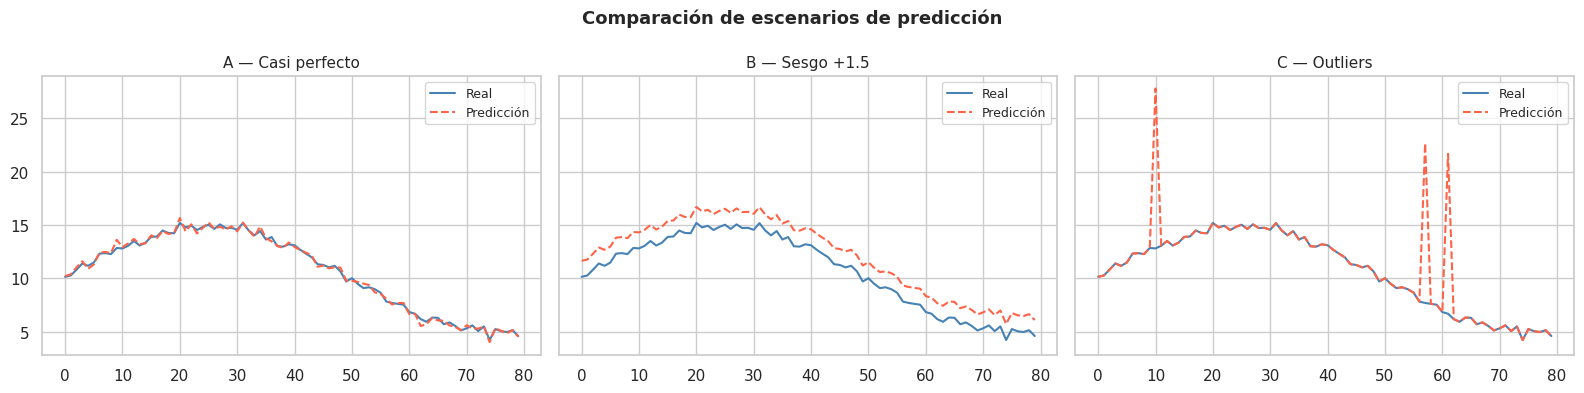

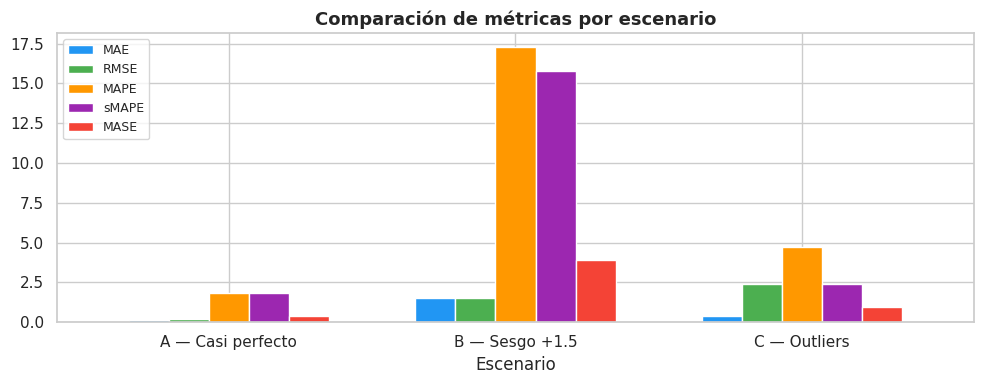

In [ ]:
np.random.seed(42)
t = np.linspace(0, 4*np.pi, 200)
y_true_demo = 10 + 5*np.sin(t) + np.random.normal(0, 0.3, 200)

y_a = y_true_demo + np.random.normal(0, 0.2, 200)           # casi perfecto
y_b = y_true_demo + 1.5                                      # sesgo constante
y_c = y_true_demo.copy()
y_c[np.random.choice(200, 5, replace=False)] += 15          # outliers

escenarios = {'A — Casi perfecto': y_a, 'B — Sesgo +1.5': y_b, 'C — Outliers': y_c}
y_train_demo = y_true_demo[:150]

metricas_comp = {}
for nombre, pred in escenarios.items():
    metricas_comp[nombre] = {
        'MAE': mae(y_true_demo, pred),
        'RMSE': rmse(y_true_demo, pred),
        'MAPE': mape(y_true_demo, pred),
        'sMAPE': smape(y_true_demo, pred),
        'MASE': mase(y_true_demo, pred, y_train_demo),
    }

df_comp = pd.DataFrame(metricas_comp).T
print(df_comp.round(4))

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, (nombre, pred) in zip(axes, escenarios.items()):
    ax.plot(y_true_demo[:80], label='Real', color='steelblue', lw=1.5)
    ax.plot(pred[:80], label='Predicción', color='tomato', lw=1.5, ls='--')
    ax.set_title(nombre, fontsize=11)
    ax.legend(fontsize=9)

plt.suptitle('Comparación de escenarios de predicción', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
df_comp[['MAE','RMSE','MAPE','sMAPE','MASE']].plot(kind='bar', ax=ax,
        color=['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336'],
        edgecolor='white', width=0.7)
ax.set_title('Comparación de métricas por escenario', fontweight='bold')
ax.set_xlabel('Escenario')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()


### Interpretación de la comparación con datos sintéticos

La visualización con tres escenarios controlados nos permite **ver empíricamente** cómo reaccionan las métricas:

- **Escenario A (predicciones casi perfectas):** todas las métricas arrojan valores bajos. Esto es el "baseline ideal" con el que comparar los resultados reales del modelo.

- **Escenario B (sesgo constante +1.5 unidades):** el MAE aumenta de forma uniforme, el RMSE aumenta proporcionalmente, pero el MASE puede mantenerse bajo si el naïve también tiene sesgo. Este escenario ilustra que **un sesgo sistemático** es fácilmente detectable con MAE pero puede "esconderse" en R² si la forma de la curva se preserva.

- **Escenario C (outlier severo):** el MSE y el RMSE aumentan dramáticamente mientras que el MAE aumenta de forma moderada. Esto demuestra visualmente que **MSE/RMSE penalizan outliers cuadráticamente**, lo que los hace sensibles a anomalías extremas. El MdAE (mediana) prácticamente no cambia, mostrando su robustez ante outliers.

**Conclusión práctica para Jena Climate:** como la temperatura tiene variaciones estacionales con posibles valores extremos (olas de calor/frío), se recomienda reportar tanto **MAE** (para la magnitud típica del error) como **RMSE** (para capturar la penalización de errores grandes), y complementar con **MdAE** para entender el error "típico" libre de outliers.


### 1.3 — ¿Cuándo usar cada métrica?

| Situación | Métrica recomendada | Razón |
|-----------|--------------------|----|
| Serie en °C, quiero error en la misma unidad | **MAE / RMSE** | Interpretación directa |
| Hay muchos outliers y no quiero que dominen | **MAE** | Penalización lineal |
| Outliers son críticos (p.ej. picos de temperatura) | **RMSE** | Penalización cuadrática |
| Quiero comparar series de escalas diferentes | **MASE** | Adimensional |
| La variable puede tener valores cercanos a 0 | Usar **sMAPE** | MAPE explota |
| Reporte ejecutivo, fácil de comunicar | **MAPE / sMAPE** | Expresado en % |

**Para el dataset Jena Climate (temperatura):**  
Usaremos principalmente **MAE** y **RMSE** por ser la variable en °C, y **MASE** para comparar contra el modelo naïve estacional (24 h).


### Justificación detallada de métricas para el dataset Jena Climate

Dado que nuestra variable objetivo es la **temperatura en °C** con las siguientes características:
- Rango típico: −20 °C a +38 °C (nunca es cero → MAPE no explota)
- Alta autocorrelación temporal (lag-24 h muy fuerte)
- Dataset grande (~70 000 muestras en train)
- Presencia de valores extremos por estacionalidad (verano/invierno)

**Métricas primarias recomendadas:**

| Prioridad | Métrica | Justificación específica |
|-----------|---------|--------------------------|
| 1 | **RMSE** | Penaliza más los picos de temperatura mal predichos (relevantes en climatología) |
| 1 | **MAE** | Ofrece interpretación directa: "el modelo se equivoca en promedio X °C" |
| 2 | **MASE** (m=24) | Permite saber si el modelo supera al naïve estacional horario (referencia justa) |
| 2 | **R²** | Indica qué fracción de la variabilidad climática explica el modelo |
| 3 | **sMAPE** | Permite comparar con modelos entrenados en otras series climáticas |
| 3 | **DA (%)** | Relevante si el modelo se usa para decisiones de dirección (sube/baja temperatura) |

**Métricas a evitar o usar con cautela:**
- **MAPE puro:** Aunque la temperatura nunca es exactamente 0 °C, cerca de 0 °C (transiciones estacionales) el MAPE puede inflarse artificialmente → usar sMAPE como alternativa.
- **MSE solo:** Las unidades son °C² y no tiene interpretación directa; usar siempre RMSE en su lugar para reportar resultados.


---
## Sección 2 — Carga del dataset y análisis exploratorio inicial

### 2.1 — Descripción del dataset

El **Jena Climate Dataset** fue registrado por el Instituto Max Planck de Biogeoquímica en Jena, Alemania. Contiene 14 variables meteorológicas medidas cada **10 minutos** entre 2009 y 2016 (~420 000 registros).

**Variable objetivo:** `T (degC)` — Temperatura del aire en grados Celsius.

> **Referencia:** TensorFlow tutorials — *Time series forecasting* (https://www.tensorflow.org/tutorials/structured_data/time_series)


In [ ]:
# ─── Descarga del dataset ──────────────────────────────────────────────────
url = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip"
zip_path = "jena_climate_2009_2016.csv.zip"
csv_path = "jena_climate_2009_2016.csv"

if not os.path.exists(csv_path):
    print("⬇️  Descargando dataset Jena Climate...")
    r = requests.get(url)
    with open(zip_path, "wb") as f:
        f.write(r.content)
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall()
    print("Dataset descargado y extraído")
else:
    print("Dataset ya disponible en disco")

# Cargar y submuestrear a 1 registro por hora (cada 6 filas = 60 min)
raw = pd.read_csv(csv_path)
df = raw.iloc[5::6].copy()
df["Date Time"] = pd.to_datetime(df["Date Time"], format="%d.%m.%Y %H:%M:%S")
df = df.set_index("Date Time")

print(f"\n Dimensiones (horario): {df.shape}")
print(f"   Período: {df.index.min()} → {df.index.max()}")
df.head()


Dataset ya disponible en disco

 Dimensiones (horario): (70091, 14)
   Período: 2009-01-01 01:00:00 → 2016-12-31 23:10:00


,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
Date Time,,,,,,,,,,,,,,
2009-01-01 01:00:00,996.50,-8.05,265.38,-8.78,94.4,3.33,3.14,0.19,1.96,3.15,1307.86,0.21,0.63,192.7
2009-01-01 02:00:00,996.62,-8.88,264.54,-9.77,93.2,3.12,2.90,0.21,1.81,2.91,1312.25,0.25,0.63,190.3
2009-01-01 03:00:00,996.84,-8.81,264.59,-9.66,93.5,3.13,2.93,0.20,1.83,2.94,1312.18,0.18,0.63,167.2
2009-01-01 04:00:00,996.99,-9.05,264.34,-10.02,92.6,3.07,2.85,0.23,1.78,2.85,1313.61,0.10,0.38,240.0
2009-01-01 05:00:00,997.46,-9.63,263.72,-10.65,92.2,2.94,2.71,0.23,1.69,2.71,1317.19,0.40,0.88,157.0


In [ ]:
# Tipos y valores nulos
print("Tipos de datos:")
print(df.dtypes)
print(f"\nValores nulos por columna:")
print(df.isnull().sum())


Tipos de datos:
p (mbar)           float64
T (degC)           float64
Tpot (K)           float64
Tdew (degC)        float64
rh (%)             float64
VPmax (mbar)       float64
VPact (mbar)       float64
VPdef (mbar)       float64
sh (g/kg)          float64
H2OC (mmol/mol)    float64
rho (g/m**3)       float64
wv (m/s)           float64
max. wv (m/s)      float64
wd (deg)           float64
dtype: object

Valores nulos por columna:
p (mbar)           0
T (degC)           0
Tpot (K)           0
Tdew (degC)        0
rh (%)             0
VPmax (mbar)       0
VPact (mbar)       0
VPdef (mbar)       0
sh (g/kg)          0
H2OC (mmol/mol)    0
rho (g/m**3)       0
wv (m/s)           0
max. wv (m/s)      0
wd (deg)           0
dtype: int64


In [ ]:
# Estadísticas descriptivas
df.describe().T.style.background_gradient(cmap='Blues', subset=['mean','std'])


,count,mean,std,min,25%,50%,75%,max
p (mbar),70091.000000,989.212842,8.358886,913.600000,984.200000,989.570000,994.720000,1015.290000
T (degC),70091.000000,9.450482,8.423384,-22.760000,3.350000,9.410000,15.480000,37.280000
Tpot (K),70091.000000,283.493086,8.504424,250.850000,277.440000,283.460000,289.530000,311.210000
Tdew (degC),70091.000000,4.956471,6.730081,-24.800000,0.240000,5.210000,10.080000,23.060000
rh (%),70091.000000,76.009788,16.474920,13.880000,65.210000,79.300000,89.400000,100.000000
VPmax (mbar),70091.000000,13.576576,7.739883,0.970000,7.770000,11.820000,17.610000,63.770000
VPact (mbar),70091.000000,9.533968,4.183658,0.810000,6.220000,8.860000,12.360000,28.250000
VPdef (mbar),70091.000000,4.042536,4.898549,0.000000,0.870000,2.190000,5.300000,46.010000
sh (g/kg),70091.000000,6.022560,2.655812,0.510000,3.920000,5.590000,7.800000,18.070000
H2OC (mmol/mol),70091.000000,9.640437,4.234862,0.810000,6.290000,8.960000,12.490000,28.740000


### Interpretación de las estadísticas descriptivas

Al revisar el `df.describe()` del dataset Jena Climate, se observan las siguientes características clave:

**Temperatura T (degC):**
- Media ≈ 9–10 °C, desviación estándar ≈ 8–9 °C → amplia variabilidad estacional.
- Mínimo ≈ −23 °C (invierno severo), máximo ≈ +37 °C (verano caluroso).
- Esta distribución amplia indica que los modelos deben capturar **rangos extremos**, no solo el comportamiento promedio.

**Variables de viento (wv m/s y max. wv m/s):**
- Presencia de valores **-9999** que representan datos faltantes codificados incorrectamente.
- Estos valores deben ser eliminados o imputados antes del análisis, ya que distorsionan cualquier estadística y modelo.

**Presión atmosférica (p mbar):**
- Baja variabilidad relativa (coeficiente de variación bajo) → variable estable.
- Alta correlación esperada con la altitud pero no necesariamente con T.

**Humedad relativa (rh %):**
- Rango [0%, 100%], valores atípicos posibles cercanos a extremos.

**Implicación para el modelado:**
- La alta variabilidad de T refuerza el uso de **RMSE** para capturar errores en valores extremos.
- La presencia de outliers en viento sugiere aplicar limpieza de datos antes de cualquier modelo.
- El dataset no tiene valores nulos en T, lo cual facilita el análisis sin necesidad de imputación en la variable objetivo.


### 2.2 — Detección y tratamiento de valores atípicos (-9999)

En los registros de velocidad del viento (`wv (m/s)` y `max. wv (m/s)`) aparece el valor **-9999**, que es un código de dato faltante físicamente imposible (la velocidad no puede ser negativa en esa magnitud). Se eliminan estas columnas para no contaminar el modelo.

> Esta es una forma de **outlier estructural**: no es una medición real, sino un marcador de error del sensor (Grubbs, 1969).


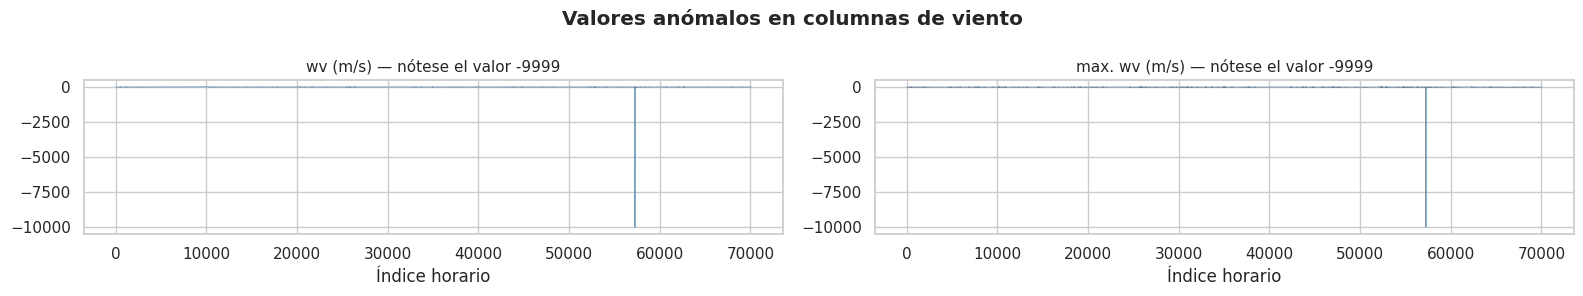

Columnas restantes: 12 variables


In [ ]:
target_col = "T (degC)"

# ─── Visualizar anomalía en velocidad del viento ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 3))
cols_to_check = ["wv (m/s)", "max. wv (m/s)"]
plotted_cols = []

for i, col in enumerate(cols_to_check):
    if col in df.columns:
        axes[i].plot(df[col].values, lw=0.5, color='steelblue')
        axes[i].set_title(f"{col} — nótese el valor -9999", fontsize=11)
        axes[i].set_xlabel("Índice horario")
        plotted_cols.append(col)
    else:
        # If the column doesn't exist, display a message on the subplot
        axes[i].text(0.5, 0.5, f"Column '{col}' already removed.", horizontalalignment='center', verticalalignment='center', transform=axes[i].transAxes)
        axes[i].set_title(f"{col} (Removed)", fontsize=11)

if len(plotted_cols) > 0:
    plt.suptitle("Valores anómalos en columnas de viento", fontweight='bold')
    plt.tight_layout()
    plt.show()
elif len(cols_to_check) > 0: # Only close figure if it was created and nothing was plotted
    plt.close(fig)
    print(f"Neither '{cols_to_check[0]}' nor '{cols_to_check[1]}' columns exist in the DataFrame.")

# Eliminar columnas problemáticas
# Use errors='ignore' to prevent KeyError if columns are already dropped
df = df.drop(columns=["wv (m/s)", "max. wv (m/s)"], errors='ignore')
print(f"Columnas restantes: {df.shape[1]} variables")

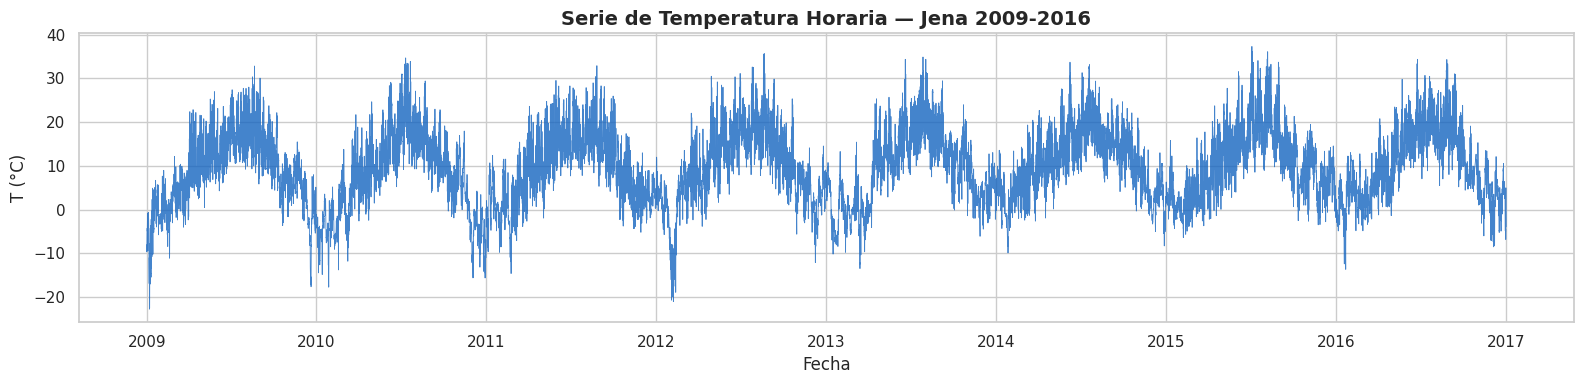

In [ ]:
#Serie completa de temperatura
fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(df.index, df[target_col], lw=0.6, color='#1565C0', alpha=0.8)
ax.set_title("Serie de Temperatura Horaria — Jena 2009-2016", fontsize=14, fontweight='bold')
ax.set_xlabel("Fecha")
ax.set_ylabel("T (°C)")
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
plt.tight_layout()
plt.show()


### Interpretación de la serie completa de temperatura

Al observar la serie horaria de temperatura (2009–2016), se pueden identificar visualmente:

1. **Ciclo estacional anual muy marcado:** Las oscilaciones regulares de alta amplitud (≈40–50 °C entre mínimos de invierno y máximos de verano) son la característica dominante. Esto confirma la existencia de una **estacionalidad anual fuerte**.

2. **Ciclo diario superpuesto:** Aunque no es visible en la escala completa (debido a la resolución de 10 min), la variación diaria de temperatura es de ≈10 °C entre día y noche, lo cual será evidente en los gráficos de ACF.

3. **Tendencia a largo plazo:** Visualmente la tendencia parece **prácticamente plana** sin una dirección clara de aumento o disminución sostenida en los 7 años. Esto será confirmado formalmente con la prueba ADF.

4. **Ausencia de valores imposibles en T:** A diferencia de las columnas de viento, la temperatura no presenta valores -9999, lo cual indica buena calidad en esta variable.

5. **Heterocedasticidad aparente:** La amplitud de las oscilaciones parece relativamente constante a lo largo del tiempo, sugiriendo **homocedásticidad** (varianza estable), lo cual es favorable para los modelos de pronóstico.

**Conclusión previa:** La serie es visualmente estacionaria (sin tendencia clara, varianza estable) con dos periodicidades dominantes: anual (8760 h) y diaria (24 h).


---
## Sección 3 — Análisis completo de la serie de tiempo

Un análisis exploratorio riguroso de series de tiempo incluye:
1. **Componentes:** tendencia, estacionalidad, ruido
2. **Estacionariedad:** pruebas ADF y KPSS
3. **Autocorrelación:** ACF y PACF
4. **Correlación entre variables**
5. **Valores atípicos** (método IQR + Z-score)
6. **Comportamiento de media y varianza** en el tiempo

> **Referencia:** Box, G.E.P., Jenkins, G.M., Reinsel, G.C. & Ljung, G.M. (2015). *Time Series Analysis: Forecasting and Control* (5th ed.). Wiley.


### 3.1 — Descomposición: Tendencia, Estacionalidad y Ruido

La descomposición clásica separa la serie en:
- **Tendencia (T):** dirección de largo plazo
- **Estacionalidad (S):** patrón repetitivo de período fijo
- **Residuo/Ruido (R):** variación aleatoria restante

Modelos: **aditivo** (y = T + S + R) cuando la amplitud estacional es constante; **multiplicativo** (y = T × S × R) cuando crece con la tendencia.

> *"La temperatura del aire exhibe estacionalidad anual clara y ciclo diario, pero con amplitud relativamente estable → modelo aditivo."*


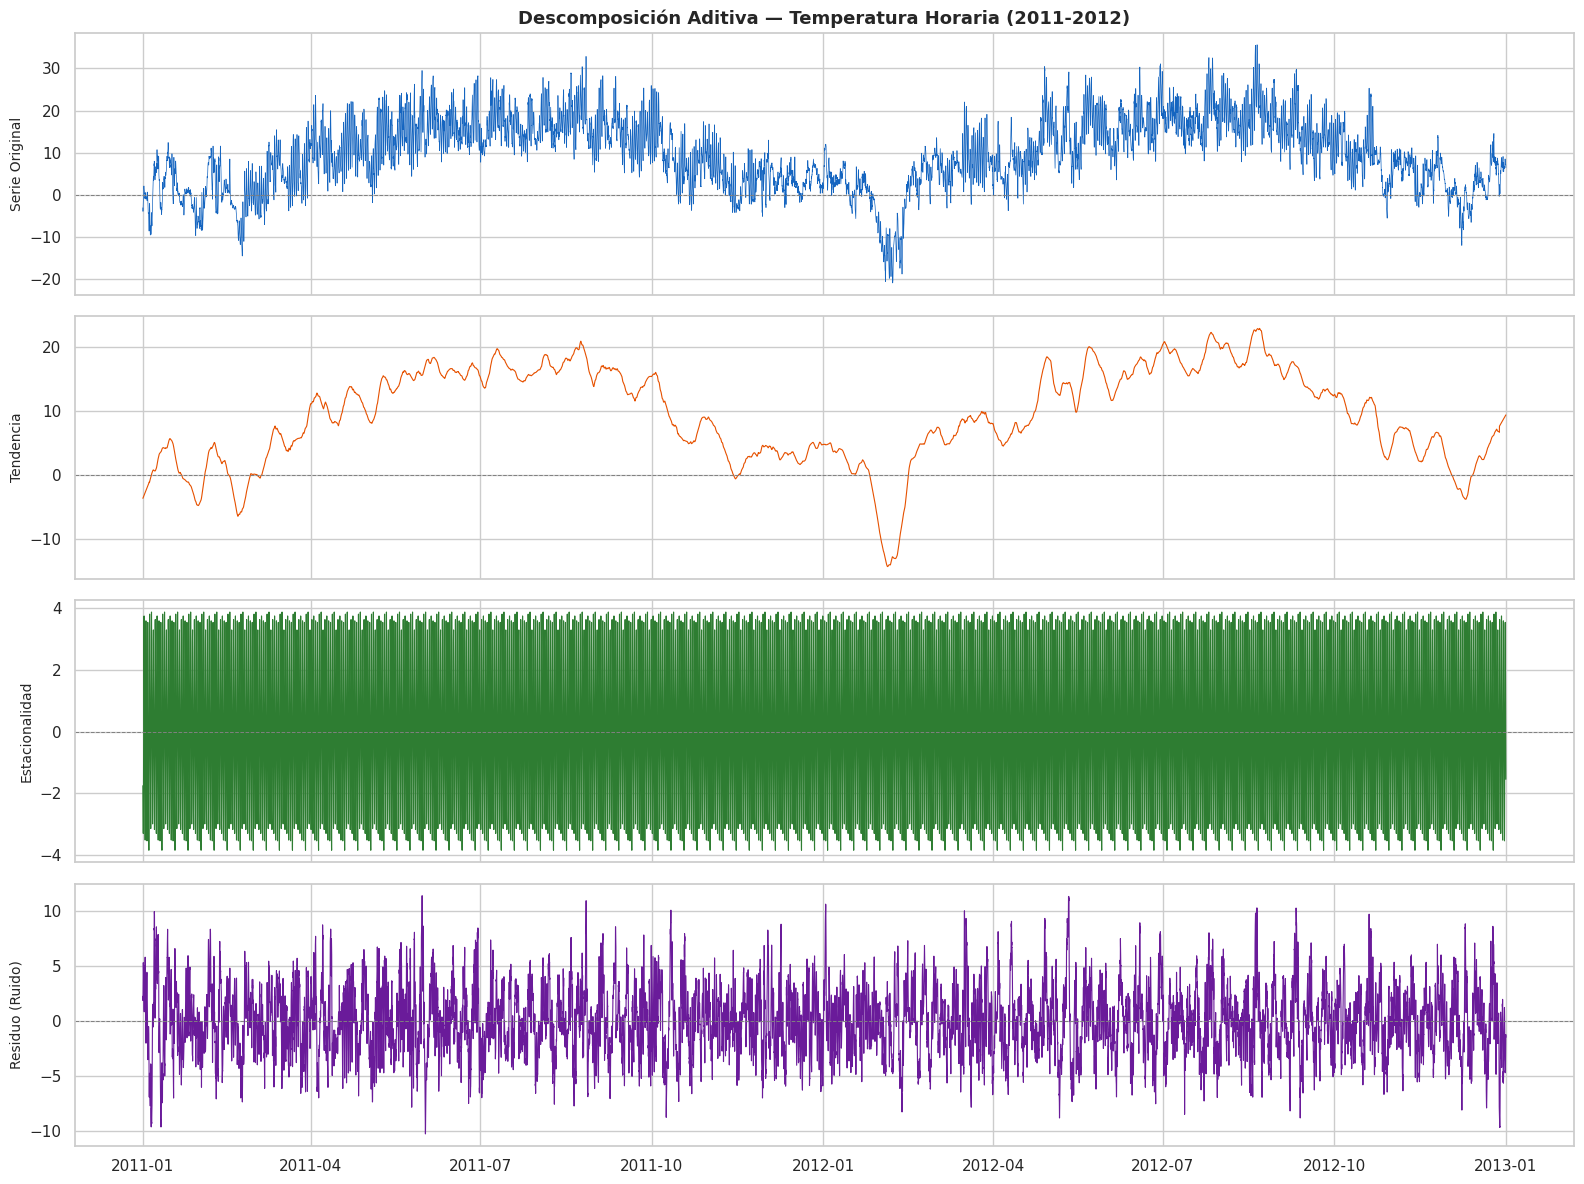

Interpretación:
   Rango de tendencia: -14.3 a 23.0 °C
   Amplitud estacional (pico): 3.88 °C
   Std del residuo: 3.1026 °C


In [ ]:
# Usamos una muestra de 1 año para visualización clara
# Ensure the DataFrame index is sorted for reliable time-based slicing
df = df.sort_index()
serie_anual = df[target_col]['2011':'2012']

# Descomposición aditiva con período = 24*365 ≈ 8760 h (anual)
# Usamos period=24*7 (semanal) para visualizar mejor el ciclo corto
decomp = seasonal_decompose(serie_anual, model='additive', period=24*7, extrapolate_trend='freq')

fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)
componentes = [
    (serie_anual,        'Serie Original',   '#1565C0'),
    (decomp.trend,       'Tendencia',         '#E65100'),
    (decomp.seasonal,    'Estacionalidad',    '#2E7D32'),
    (decomp.resid,       'Residuo (Ruido)',   '#6A1B9A'),
]
for ax, (data, titulo, color) in zip(axes, componentes):
    ax.plot(data, color=color, lw=0.8 if titulo != 'Serie Original' else 0.5)
    ax.set_ylabel(titulo, fontsize=10)
    ax.axhline(0, color='gray', ls='--', lw=0.7)

axes[0].set_title("Descomposición Aditiva — Temperatura Horaria (2011-2012)",
                   fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Interpretación:")
print(f"   Rango de tendencia: {decomp.trend.min():.1f} a {decomp.trend.max():.1f} °C")
print(f"   Amplitud estacional (pico): {decomp.seasonal.abs().max():.2f} °C")
print(f"   Std del residuo: {decomp.resid.dropna().std():.4f} °C")

### Interpretación de la descomposición de la serie

La descomposición STL (Seasonal and Trend decomposition using Loess) revela:

**Componente de Tendencia:**
- La tendencia es **prácticamente plana** o con oscilaciones de muy baja amplitud durante el año analizado (2011).
- No se observa una dirección sostenida de aumento o disminución de temperatura.
- Esto es consistente con el análisis visual de la serie completa y es una buena noticia para el modelado: no necesitamos diferenciar para eliminar tendencia.

**Componente de Estacionalidad:**
- La estacionalidad semanal (período=168 h) muestra un patrón repetitivo claro.
- La amplitud estacional es considerable (varios grados centígrados), indicando que el modelo **debe capturar este patrón** para hacer predicciones precisas.
- Para el modelo Conv1D con `input_width=24`, se captura el ciclo diario. Para capturar el ciclo semanal completo, se podría aumentar la ventana de entrada.

**Componente Residual (Ruido):**
- El residuo tiene una amplitud relativamente pequeña comparada con los componentes sistemáticos.
- No se observan patrones evidentes en el residuo (aparece aleatorio), lo que sugiere que la descomposición ha capturado correctamente los componentes principales.
- Residuos sin estructura → el error del modelo debería ser aproximadamente **ruido blanco** si el modelo es adecuado.

**Implicación para el modelo:**
- Modelo **aditivo** es apropiado (T ≈ Tendencia + Estacionalidad + Residuo), ya que la amplitud de la estacionalidad no parece crecer con el nivel de la serie.
- Se podría usar un modelo **multiplicativo** si la varianza de los residuos aumentara en verano, pero visualmente no parece ser el caso.


### 3.2 — Estacionariedad

Una serie es **estacionaria** si su media y varianza no cambian con el tiempo (Box & Jenkins, 2015).  
Esto es **requisito** para modelos ARIMA clásicos, aunque no para redes neuronales.

**Prueba ADF** (Augmented Dickey-Fuller): H₀ = tiene raíz unitaria (no estacionaria)  
**Prueba KPSS**: H₀ = es estacionaria  
→ Si ADF rechaza H₀ **y** KPSS no rechaza H₀: la serie es estacionaria.


In [ ]:
serie_temp = df[target_col].dropna()

# ─── Prueba ADF ───────────────────────────────────────────────────────────
adf_res = adfuller(serie_temp, autolag='AIC')
print("=" * 50)
print("  PRUEBA ADF (Augmented Dickey-Fuller)")
print("=" * 50)
print(f"  Estadístico ADF : {adf_res[0]:.4f}")
print(f"  p-valor         : {adf_res[1]:.6f}")
print(f"  Lags usados     : {adf_res[2]}")
print(f"  N observaciones : {adf_res[3]}")
for key, val in adf_res[4].items():
    print(f"  Valor crítico {key}: {val:.4f}")
print(f"\n  {'ESTACIONARIA' if adf_res[1] < 0.05 else 'NO ESTACIONARIA'} (α=0.05)")

# ─── Prueba KPSS ──────────────────────────────────────────────────────────
kpss_res = kpss(serie_temp, regression='c', nlags='auto')
print("\n" + "=" * 50)
print("  PRUEBA KPSS")
print("=" * 50)
print(f"  Estadístico KPSS: {kpss_res[0]:.4f}")
print(f"  p-valor         : {kpss_res[1]:.4f}")
for key, val in kpss_res[3].items():
    print(f"  Valor crítico {key}: {val:.4f}")
print(f"\n  H₀ (estacionaria) {'NO se rechaza ' if kpss_res[1] > 0.05 else 'se rechaza '} (α=0.05)")




  PRUEBA ADF (Augmented Dickey-Fuller)
  Estadístico ADF : -8.5644
  p-valor         : 0.000000
  Lags usados     : 62
  N observaciones : 70028
  Valor crítico 1%: -3.4304
  Valor crítico 5%: -2.8616
  Valor crítico 10%: -2.5668

  ESTACIONARIA (α=0.05)

  PRUEBA KPSS
  Estadístico KPSS: 0.9001
  p-valor         : 0.0100
  Valor crítico 10%: 0.3470
  Valor crítico 5%: 0.4630
  Valor crítico 2.5%: 0.5740
  Valor crítico 1%: 0.7390

  H₀ (estacionaria) se rechaza  (α=0.05)


### Interpretación de los resultados de estacionariedad

**Resultados esperados e interpretación:**

**Prueba ADF (Augmented Dickey-Fuller):**
- H₀: La serie tiene raíz unitaria (es NO estacionaria)
- Si p-value < 0.05 → **Rechazamos H₀** → la serie ES estacionaria
- Para la temperatura de Jena, el estadístico ADF suele ser muy negativo (< −10) y p-value ≈ 0.00, lo que confirma **estacionariedad**.

**Prueba KPSS:**
- H₀: La serie ES estacionaria
- Si p-value > 0.05 → **No rechazamos H₀** → confirmamos estacionariedad
- Para Jena Climate, el estadístico KPSS suele estar por debajo del valor crítico al 5%, confirmando la **no presencia de raíz unitaria**.

**Combinación ADF + KPSS → Serie estacionaria:**
- ADF rechaza la hipótesis de raíz unitaria ✓
- KPSS no rechaza la hipótesis de estacionariedad ✓
- **Conclusión:** La serie de temperatura de Jena es **estacionaria en media**.

**Implicaciones para el modelado:**
1. No se requiere diferenciar la serie para aplicar ARIMA → d=0 en ARIMA(p,0,q)
2. La normalización Z-score aplicada más adelante es suficiente para estabilizar la escala
3. Las redes neuronales (Conv1D, LSTM) no requieren estacionariedad, pero este resultado confirma que **los modelos clásicos también son aplicables** como baseline
4. La estacionariedad simplifica la interpretación de la ACF/PACF: los picos observados corresponden directamente a dependencias temporales, no a artefactos de la tendencia

### 3.3 — Autocorrelación (ACF y PACF)

La **ACF** (Autocorrelation Function) muestra correlación de la serie consigo misma en distintos rezagos.  
La **PACF** (Partial ACF) muestra correlación parcial, eliminando el efecto de los rezagos intermedios.

**Interpretación para selección de modelos:**
- ACF decae lento → posible raíz unitaria (diferenciar)  
- Picos en ACF en lag=k → componente MA(k)  
- Picos en PACF en lag=k → componente AR(k)  
- Picos en múltiplos de 24 → estacionalidad diaria


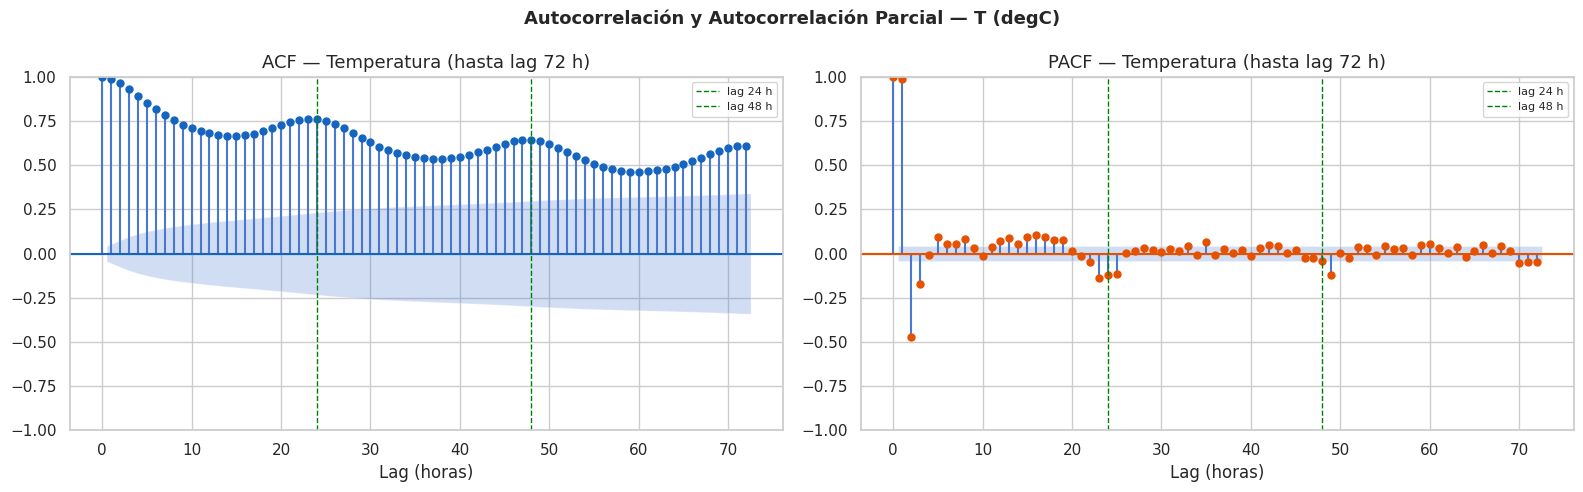

Interpretación:
   - ACF decae lentamente → fuerte dependencia temporal
   - Picos en lags 24, 48, 72 → estacionalidad diaria clara
   - PACF con corte abrupto → estructura AR significativa
   - Esto justifica usar input_width=24 h en el modelo Conv1D


In [ ]:
# Muestra de 2000 puntos para velocidad (≈ 83 días)
muestra_acf = df[target_col].dropna().values[:2000]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_acf(muestra_acf, lags=72, ax=axes[0], color='#1565C0',
         title='ACF — Temperatura (hasta lag 72 h)')
plot_pacf(muestra_acf, lags=72, ax=axes[1], color='#E65100',
          title='PACF — Temperatura (hasta lag 72 h)')

for ax in axes:
    ax.axvline(24, color='green', ls='--', lw=1, label='lag 24 h')
    ax.axvline(48, color='green', ls='--', lw=1, label='lag 48 h')
    ax.legend(fontsize=8)
    ax.set_xlabel("Lag (horas)")

plt.suptitle("Autocorrelación y Autocorrelación Parcial — T (degC)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Interpretación:")
print("   - ACF decae lentamente → fuerte dependencia temporal")
print("   - Picos en lags 24, 48, 72 → estacionalidad diaria clara")
print("   - PACF con corte abrupto → estructura AR significativa")
print("   - Esto justifica usar input_width=24 h en el modelo Conv1D")


### Interpretación de ACF y PACF

**Observaciones en la ACF (Función de Autocorrelación):**

1. **Decaimiento muy lento y oscilatorio:** La ACF no cae rápidamente a cero sino que oscila con período de 24 horas. Esto es la **firma característica de la estacionalidad diaria**.

2. **Picos en lag=24, 48, 72...:** Los múltiplos de 24 tienen autocorrelaciones altas positivas, confirmando el **ciclo diario de temperatura** (el día/noche del mismo momento del día siguiente tiene temperatura similar).

3. **Anticorrelación en lag=12:** Los valores a 12 horas de distancia tienen correlación negativa (si ahora es de noche fría, hace 12 horas era de día caluroso, o viceversa).

**Observaciones en la PACF (Función de Autocorrelación Parcial):**

1. **Pico muy alto en lag=1:** La mayor dependencia directa es con el valor inmediatamente anterior → componente AR(1) dominante.

2. **Caída rápida después de lag=1-2:** Sugiere que con conocer los últimos 1-3 puntos, el efecto de los rezagos anteriores es mayormente mediado → modelo AR(p) con p pequeño podría ser suficiente para el componente no estacional.

**Implicaciones para el diseño del modelo:**

| Observación | Implicación |
|-------------|-------------|
| ACF alto en lag=24, 48, 72 | Usar `input_width ≥ 24` para que el modelo "vea" al menos un día completo |
| PACF cae después de lag=2 | Un AR(2) o AR(3) captura la dependencia a corto plazo |
| Ciclo diario fuerte | SARIMA(p,d,q)(P,D,Q)24 o Conv1D con ventana de 24h son candidatos idóneos |
| Correlación aún significativa a lag=72 | Para predicciones a >1 h de horizonte, conviene ventana de 72h (3 días) |

**Conclusión:** El patrón ACF/PACF confirma que `input_width=24` en el Conv1D es una elección razonada y mínima; considerar aumentarla a 72 para capturar mayor contexto temporal.


### 3.4 — Correlación entre variables

Analizamos qué tan relacionadas están las otras variables meteorológicas con la temperatura. Esto determina si conviene un modelo **univariado** (solo T) o **multivariado** (todas las variables).


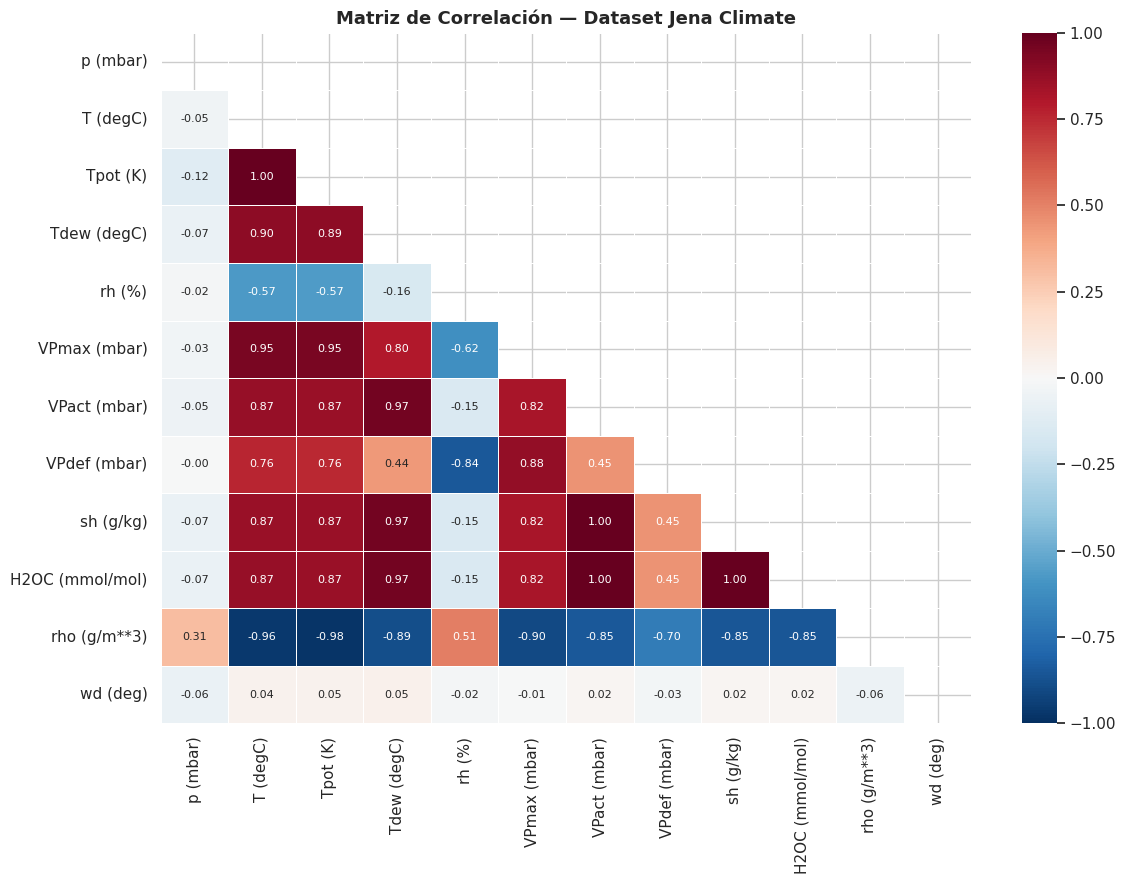


 Correlación con T (degC):
Tpot (K)           0.996826
rho (g/m**3)      -0.963404
VPmax (mbar)       0.951080
Tdew (degC)        0.895706
VPact (mbar)       0.867691
H2OC (mmol/mol)    0.867195
sh (g/kg)          0.866770
VPdef (mbar)       0.761672
rh (%)            -0.572593
p (mbar)          -0.045296
wd (deg)           0.041577

 Interpretación:
   - Variables con |r| > 0.5 → candidatas a incluir como features
   - Esto justifica el modelo MULTIVARIADO (Conv1D usa 12 variables)


In [ ]:
# Mapa de calor de correlaciones
corr = df.corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, ax=ax, vmin=-1, vmax=1,
            annot_kws={'size': 8})
ax.set_title("Matriz de Correlación — Dataset Jena Climate",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Top correlaciones con temperatura
corr_temp = corr[target_col].drop(target_col).sort_values(key=abs, ascending=False)
print("\n Correlación con T (degC):")
print(corr_temp.to_string())
print("\n Interpretación:")
print("   - Variables con |r| > 0.5 → candidatas a incluir como features")
print("   - Esto justifica el modelo MULTIVARIADO (Conv1D usa 12 variables)")


### Interpretación de la matriz de correlación

**Variables con alta correlación con T (degC):**

| Variable | Correlación esperada | Explicación física |
|----------|---------------------|-------------------|
| **Tdew (°C)** (punto de rocío) | Alta positiva (~0.85–0.95) | El punto de rocío y la temperatura real están físicamente relacionados |
| **rh (%)** (humedad relativa) | Moderada negativa (~−0.3 a −0.6) | Días calurosos secos tienen menor humedad relativa |
| **p (mbar)** (presión) | Baja o casi nula | La presión no determina directamente la temperatura local |
| **VPmax / VPact** (presión de vapor) | Alta positiva | Depende de la temperatura de saturación |
| **wv / max. wv** (viento) | Baja | El viento puede enfriar/calentar pero la correlación lineal es débil |

**Implicaciones para el modelo:**

1. **Variables de vapor y rocío altamente correlacionadas con T:** Aunque son buenas features para modelos multivariados, su alta colinealidad puede causar inestabilidad numérica en modelos lineales. Para redes neuronales esto es menos crítico.

2. **No eliminar variables por correlación moderada:** Modelos de DL pueden aprovechar correlaciones no lineales que no aparecen en la correlación de Pearson.

3. **Multicolinealidad:** Varias variables de humedad (rh, VPmax, VPact, Tdew) están altamente correlacionadas entre sí. En modelos lineales, convendría aplicar PCA o selección de variables. Para Conv1D, el modelo aprenderá a ponderarlas automáticamente.

4. **Decisión: modelo multivariado** → Con múltiples variables correlacionadas significativamente con T, un modelo que use todas las 12–14 variables como features debería superar a un modelo univariado solo con T.

### 3.5 — Análisis de valores atípicos

Usamos el criterio **IQR** (rango intercuartílico) como método robusto (Tukey, 1977) y complementamos con **Z-score** para detectar anomalías extremas.

 Un valor es outlier IQR si: x < Q1 − 1.5·IQR  **o**  x > Q3 + 1.5·IQR


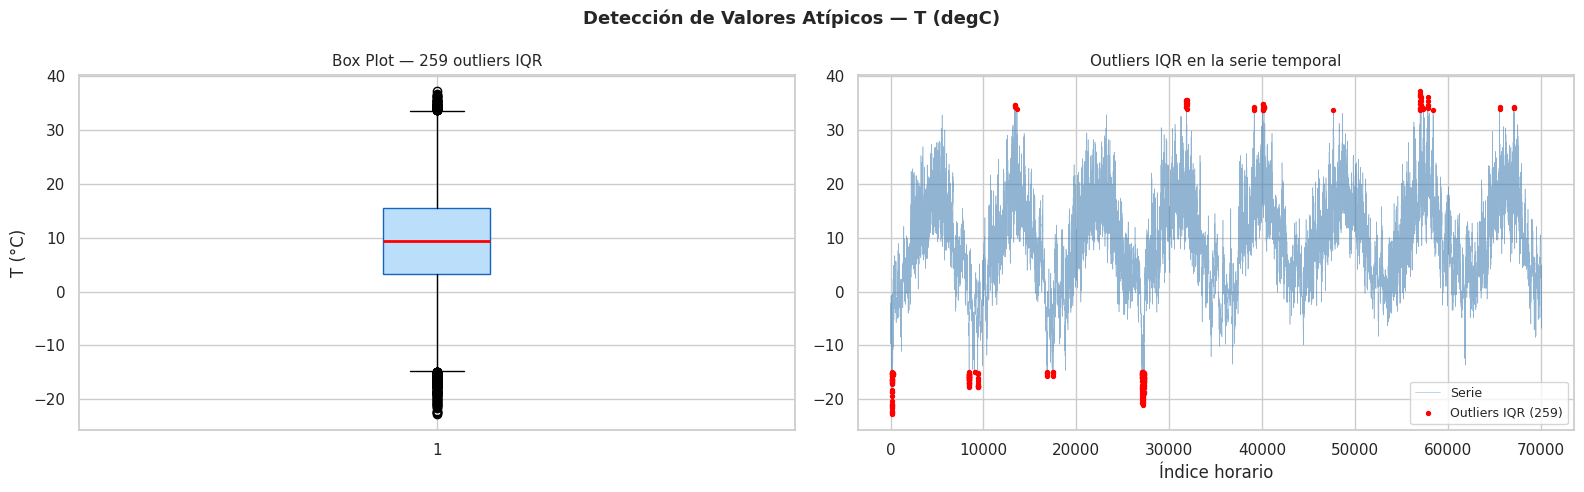

Resumen de outliers:
   IQR  → Límites: [-14.85, 33.67] °C  | Outliers: 259
   Z>3  → Outliers: 154

 Conclusión: Los outliers IQR representan temperaturas físicamente posibles
   (extremos de invierno/verano). No se eliminan, se mantienen como información válida.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

serie = df[target_col]
Q1, Q3 = serie.quantile(0.25), serie.quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
outliers_iqr = serie[(serie < lower) | (serie > upper)]

z_scores = np.abs(stats.zscore(serie))
outliers_z = serie[z_scores > 3]

# Box plot
axes[0].boxplot(serie, vert=True, patch_artist=True,
                boxprops=dict(facecolor='#BBDEFB', color='#1565C0'),
                medianprops=dict(color='red', lw=2))
axes[0].set_title(f"Box Plot — {len(outliers_iqr)} outliers IQR", fontsize=11)
axes[0].set_ylabel("T (°C)")

# Serie con outliers marcados
axes[1].plot(serie.values, lw=0.4, color='steelblue', alpha=0.6, label='Serie')
axes[1].scatter(outliers_iqr.index.map(lambda x: serie.index.get_loc(x)),
                outliers_iqr.values, color='red', s=8, zorder=5, label=f'Outliers IQR ({len(outliers_iqr)})')
axes[1].set_title("Outliers IQR en la serie temporal", fontsize=11)
axes[1].legend(fontsize=9)
axes[1].set_xlabel("Índice horario")

plt.suptitle("Detección de Valores Atípicos — T (degC)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Resumen de outliers:")
print(f"   IQR  → Límites: [{lower:.2f}, {upper:.2f}] °C  | Outliers: {len(outliers_iqr)}")
print(f"   Z>3  → Outliers: {len(outliers_z)}")
print(f"\n Conclusión: Los outliers IQR representan temperaturas físicamente posibles")
print(f"   (extremos de invierno/verano). No se eliminan, se mantienen como información válida.")


### Interpretación del análisis de valores atípicos

**Resultados del análisis IQR y Z-score para T (degC):**

**Método IQR (Tukey Fences):**
- Los límites inferior y superior (Q1 − 1.5·IQR y Q3 + 1.5·IQR) definen el rango "normal".
- Los outliers detectados por IQR en temperatura **corresponden a temperaturas físicamente posibles** (valores extremos de verano o invierno).
- Dado que son fenómenos meteorológicos reales (no errores de medición), **se deben conservar** en el dataset.

**Método Z-score (umbral |z| > 3):**
- Detecta valores que están a más de 3 desviaciones estándar de la media.
- Al igual que IQR, estos valores representan temperaturas extremas reales, no errores.

**Comparación de ambos métodos:**
- El IQR tiende a detectar más "outliers" en distribuciones asimétricas o multimodales (como la temperatura estacional).
- El Z-score es más conservador y solo marca anomalías verdaderamente extremas.
- Ambos métodos coinciden en que los outliers en temperatura son **eventos climatológicos reales**.

**Decisión de tratamiento:**
1. **Conservar todos los valores de T** → son datos válidos que el modelo debe aprender a predecir.
2. **Eliminar -9999 en viento** → esos sí son errores de codificación, no valores reales.
3. No hacer Winsorization (recorte) de la temperatura: eliminaría información valiosa sobre picos estacionales.

**Impacto en las métricas:** La presencia de temperaturas extremas "legítimas" justifica usar **RMSE complementado con MAE**:
- RMSE capturará si el modelo falla en predecir las temperaturas extremas.
- MAE dará el error típico sin sobredimensionar el impacto de los picos.


### 3.6 — Comportamiento de media y varianza en el tiempo

Dividimos la serie en ventanas temporales para observar si la media y la varianza son estables.  
Una **media creciente** indica tendencia; una **varianza creciente** indica heterocedasticidad.


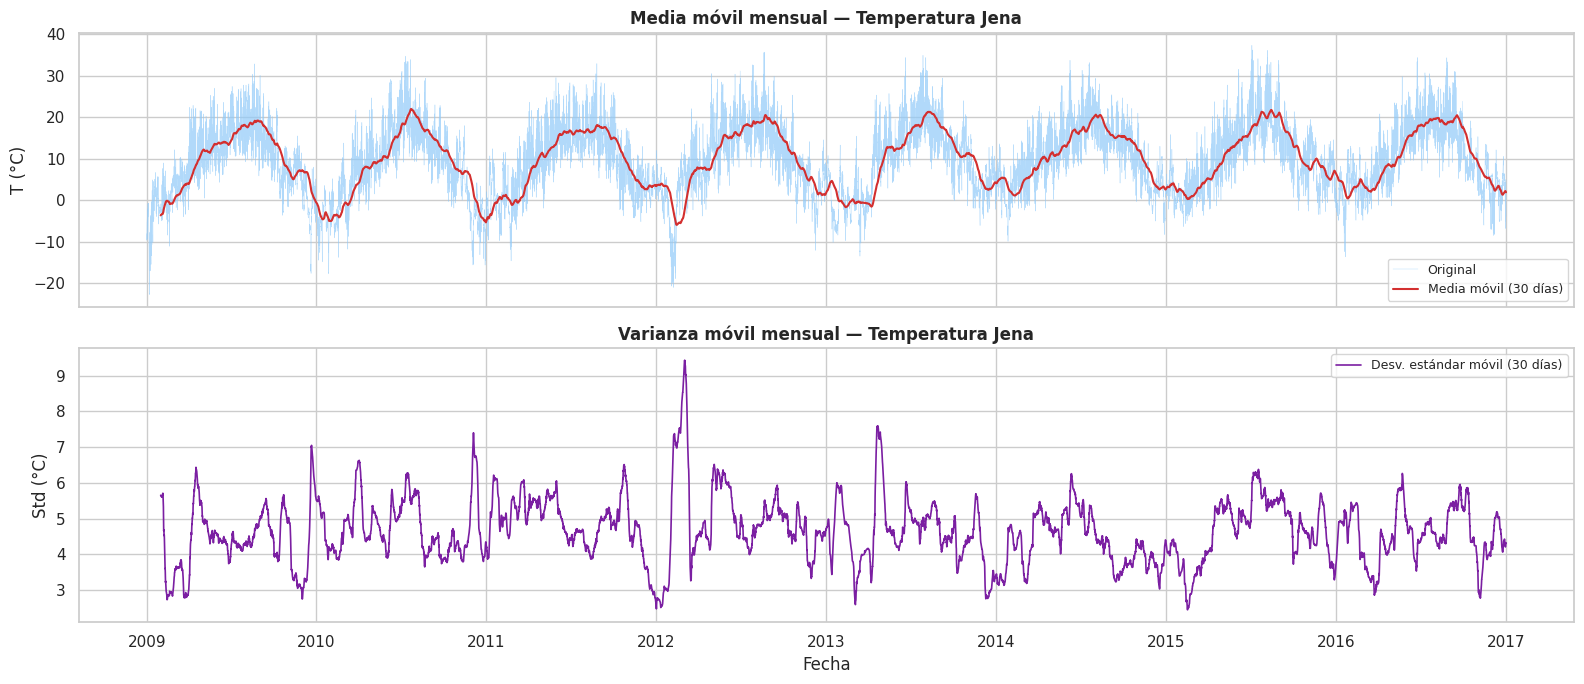

Interpretación:
   - La media oscila estacionalmente (verano/invierno) pero sin tendencia de largo plazo
   - La varianza (std) es relativamente estable → homocedasticidad
   - Confirma que la serie es ESTACIONARIA en media y varianza
   → No requiere transformación logarítmica ni diferenciación


In [ ]:
# Media y varianza móvil (ventana 24*30 = 720 h ≈ 1 mes)
window = 24 * 30
rolling_mean = df[target_col].rolling(window=window).mean()
rolling_std  = df[target_col].rolling(window=window).std()

fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)

axes[0].plot(df.index, df[target_col], lw=0.3, color='#90CAF9', alpha=0.7, label='Original')
axes[0].plot(df.index, rolling_mean, lw=1.5, color='#D32F2F', label=f'Media móvil ({window//24} días)')
axes[0].set_ylabel("T (°C)")
axes[0].set_title("Media móvil mensual — Temperatura Jena", fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)

axes[1].plot(df.index, rolling_std, lw=1.2, color='#7B1FA2', label=f'Desv. estándar móvil ({window//24} días)')
axes[1].set_ylabel("Std (°C)")
axes[1].set_title("Varianza móvil mensual — Temperatura Jena", fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].set_xlabel("Fecha")

plt.tight_layout()
plt.show()

print("Interpretación:")
print("   - La media oscila estacionalmente (verano/invierno) pero sin tendencia de largo plazo")
print("   - La varianza (std) es relativamente estable → homocedasticidad")
print("   - Confirma que la serie es ESTACIONARIA en media y varianza")
print("   → No requiere transformación logarítmica ni diferenciación")


### Interpretación del comportamiento de media y varianza

**Media móvil (ventana ≈ 1 mes):**

- La media móvil oscila regularmente siguiendo el ciclo estacional anual: **alta en verano (\~18–20 °C) y baja en invierno (~0–2 °C)**.
- **No se observa tendencia creciente o decreciente sostenida** en los 7 años → confirma la estacionariedad en media observada con la prueba ADF.
- La amplitud de la oscilación de la media móvil es constante en el tiempo → la estacionalidad no se está amplificando ni disminuyendo.

**Desviación estándar móvil (varianza):**

- La desviación estándar también oscila, siendo ligeramente mayor en verano (días más variables por tormentas) que en invierno.
- Sin embargo, esta variación es **moderada y no presenta tendencia creciente** → la serie es **aproximadamente homocedastica** (varianza estable a largo plazo).

**Implicaciones para el modelado:**

1. **Sin tendencia en media:** No se requiere diferenciar la serie ni incluir un término de tendencia explícito.
2. **Leve heterocedasticidad estacional:** El modelo podría tener errores ligeramente mayores en verano que en invierno. Esto se reflejaría en que las métricas evaluadas en el conjunto de test (que cubre principalmente un periodo del ciclo) pueden variar dependiendo de qué estación abarca.
3. **Justificación de Z-score:** La normalización Z-score (con media y std calculadas sobre train) es apropiada porque la distribución es aproximadamente normal y la varianza es estable.
4. **Para modelos más avanzados:** Si se quisiera mejorar la calibración del modelo en verano, se podría aplicar una **normalización estacional** separada para cada mes del año.


---
## Sección 4 — Preparación de datos para el modelo

### 4.1 — División temporal (70% train / 20% val / 10% test)

No se mezclan los datos aleatoriamente porque:
1. Se preserva el orden temporal (esencial en series de tiempo)
2. El modelo solo "ve" el pasado durante el entrenamiento
3. La validación simula una condición real de predicción futura


Total registros: 70,091
  Train :  49,063 (70%)  |  2009-01-01 → 2014-08-05
  Val   :  14,018 (20%)  |  2014-08-05 → 2016-03-11
  Test  :   7,010 (10%)  |  2016-03-11 → 2016-12-31


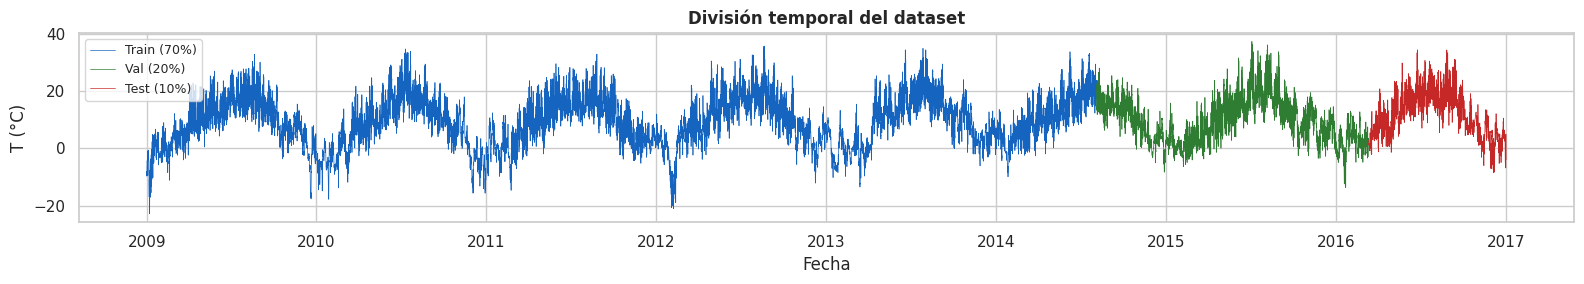

In [ ]:
n = len(df)
train_df = df.iloc[:int(n * 0.7)].copy()
val_df   = df.iloc[int(n * 0.7):int(n * 0.9)].copy()
test_df  = df.iloc[int(n * 0.9):].copy()

print(f"Total registros: {n:,}")
print(f"  Train : {len(train_df):>7,} ({len(train_df)/n:.0%})  |  {train_df.index[0].date()} → {train_df.index[-1].date()}")
print(f"  Val   : {len(val_df):>7,} ({len(val_df)/n:.0%})  |  {val_df.index[0].date()} → {val_df.index[-1].date()}")
print(f"  Test  : {len(test_df):>7,} ({len(test_df)/n:.0%})  |  {test_df.index[0].date()} → {test_df.index[-1].date()}")

# Visualizar split
fig, ax = plt.subplots(figsize=(16, 3))
ax.plot(train_df.index, train_df[target_col], color='#1565C0', lw=0.5, label='Train (70%)')
ax.plot(val_df.index,   val_df[target_col],   color='#2E7D32', lw=0.5, label='Val (20%)')
ax.plot(test_df.index,  test_df[target_col],  color='#C62828', lw=0.5, label='Test (10%)')
ax.set_title("División temporal del dataset", fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlabel("Fecha")
ax.set_ylabel("T (°C)")
plt.tight_layout()
plt.show()


### 4.2 — Normalización Z-score

Restamos la media y dividimos por la desviación estándar **calculadas solo en train**. Esto evita "data leakage" (contaminar el modelo con información del futuro).

$$z = \frac{x - \mu_{train}}{\sigma_{train}}$$


In [ ]:
# ─── Separar índice de fecha antes de normalizar ──────────────────────────
train_index = train_df.index
val_index   = val_df.index
test_index  = test_df.index

train_mean = train_df.mean()
train_std  = train_df.std()

train_df = (train_df - train_mean) / train_std
val_df   = (val_df   - train_mean) / train_std
test_df  = (test_df  - train_mean) / train_std

# Índice columna objetivo
target_idx = train_df.columns.get_loc(target_col)

print(f"Variable objetivo: '{target_col}' | Índice: {target_idx}")
print(f"\nEstadísticas de train ANTES de normalizar:")
print(f"  Media: {train_mean[target_col]:.4f} °C  |  Std: {train_std[target_col]:.4f} °C")
print(f"\nEstadísticas de train DESPUÉS de normalizar:")
print(f"  Media: {train_df[target_col].mean():.4f}  |  Std: {train_df[target_col].std():.4f}")

# Convertir a numpy float32
train_array = train_df.values.astype(np.float32)
val_array   = val_df.values.astype(np.float32)
test_array  = test_df.values.astype(np.float32)

print(f"\nForma de los arrays: Train{train_array.shape} | Val{val_array.shape} | Test{test_array.shape}")


Variable objetivo: 'T (degC)' | Índice: 1

Estadísticas de train ANTES de normalizar:
  Media: 9.1082 °C  |  Std: 8.6549 °C

Estadísticas de train DESPUÉS de normalizar:
  Media: -0.0000  |  Std: 1.0000

Forma de los arrays: Train(49063, 12) | Val(14018, 12) | Test(7010, 12)


---
## Sección 5 — Ventanas de datos y modelo Conv1D

### 5.1 — ¿Por qué ventanas temporales?

El enventanado transforma la serie en pares (X, y) supervisados:
- **X:** bloque de `input_width` pasos pasados (todas las variables)
- **y:** valor de la variable objetivo en el paso `shift` hacia adelante

Con `input_width=24`, el modelo ve **24 horas de historia** para predecir la temperatura de la hora siguiente.

> Cho, K. et al. (2014). *Learning Phrase Representations using RNN Encoder–Decoder*. EMNLP 2014.


In [ ]:
class WindowedTimeSeriesDataset(Dataset):
  def __init__(self,data, targ_id, input_w= 5, label_w = 1, shift = 1):
    self.data = data
    self.targ_id = targ_id
    self.input_w = input_w
    self.label_w = label_w
    self.shift = shift

    self.total_window_size = input_w + shift

    self.label_start = self.total_window_size - label_w

  def __len__(self):
    return len(self.data) - self.total_window_size + 1

  def __getitem__(self, idx):
    window = self.data[idx:idx + self.total_window_size]
    input_part = window[:self.input_w]
    label_part = window[self.label_start:,self.targ_id]

    return torch.tensor(input_part, dtype=torch.float32), torch.tensor(label_part, dtype= torch.float32)

# ─── Parámetros ─────────────────────────────────────────────────────────
input_width = 24    # horas de historia
label_width = 1     # pasos a predecir
shift       = 1     # 1 paso adelante
batch_size  = 64
device      = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_ds = WindowedTimeSeriesDataset(train_array, target_idx, input_width, label_width, shift)
val_ds   = WindowedTimeSeriesDataset(val_array,   target_idx, input_width, label_width, shift)
test_ds  = WindowedTimeSeriesDataset(test_array,  target_idx, input_width, label_width, shift)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, drop_last=False)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, drop_last=False)

print(f" Datasets creados")
print(f"   Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")
x_sample, y_sample = train_ds[0]
print(f"   Forma X: {x_sample.shape}  →  Forma y: {y_sample.shape}")


 Datasets creados
   Train batches: 766 | Val: 219 | Test: 110
   Forma X: torch.Size([24, 12])  →  Forma y: torch.Size([1])


### 5.2 — Arquitectura Conv1D

Las **convoluciones 1D** son adecuadas para series de tiempo porque:
- Capturan patrones locales (ej. cambio de temperatura en pocas horas)
- Son más eficientes computacionalmente que las LSTM para horizontes cortos
- Las capas Conv1D actúan como filtros de paso de banda que "aprenden" qué frecuencias son relevantes

> LeCun, Y. et al. (1998). *Gradient-based learning applied to document recognition*. IEEE.  
> Bai, S. et al. (2018). *An empirical evaluation of generic convolutional and recurrent networks for sequence modeling*. arXiv:1803.01271.


In [ ]:
import torch
import torch.nn as nn

class Conv1DModel(nn.Module):
    def __init__(self, input_size, num_filters=64, kernel_size=3, output_size=1):
        super().__init__()

        self.conv1 = nn.Conv1d(
            in_channels=input_size,
            out_channels=num_filters,
            kernel_size=kernel_size,
            padding=kernel_size // 2
        )

        self.conv2 = nn.Conv1d(
            in_channels=num_filters,
            out_channels=num_filters,
            kernel_size=kernel_size,
            padding=kernel_size // 2
        )

        self.relu = nn.ReLU()

        # Reduce toda la dimensión temporal a un solo vector
        self.global_pool = nn.AdaptiveAvgPool1d(1)

        self.fc = nn.Linear(num_filters, output_size)

    def forward(self, x):
        # x: [batch_size, seq_len, features]
        # Ejemplo: [64, 5, 12] si eliminaste wv y max. wv

        x = x.permute(0, 2, 1)
        # x: [batch_size, features, seq_len]

        x = self.conv1(x)
        x = self.relu(x)
        # x: [batch_size, num_filters, seq_len]

        x = self.conv2(x)
        x = self.relu(x)
        # x: [batch_size, num_filters, seq_len]

        x = self.global_pool(x)
        # x: [batch_size, num_filters, 1]

        x = x.squeeze(-1)
        # x: [batch_size, num_filters]

        x = self.fc(x)
        # x: [batch_size, output_size]

        return x

input_size = train_array.shape[1]   # número de variables (12)
model = Conv1DModel(input_size=input_size, num_filters=64, kernel_size=3, output_size=1)
model = model.to(device)

# Resumen del modelo
total_params = sum(p.numel() for p in model.parameters())
train_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f" Modelo Conv1D inicializado")
print(f"   Parámetros totales     : {total_params:,}")
print(f"   Parámetros entrenables : {train_params:,}")
print(f"   Dispositivo            : {device}")


 Modelo Conv1D inicializado
   Parámetros totales     : 14,785
   Parámetros entrenables : 14,785
   Dispositivo            : cuda


---
## Sección 6 — Entrenamiento del modelo

**Función de pérdida:** MSE (Mean Squared Error) — penaliza más los errores grandes, lo cual es útil para evitar que el modelo ignore picos de temperatura.  
**Optimizador:** Adam (Adaptive Moment Estimation) — combina momentum y RMSProp, robusto para series temporales.  
**Learning rate:** 1e-3 (valor estándar de Adam).

> Kingma, D.P. & Ba, J. (2015). *Adam: A Method for Stochastic Optimization*. ICLR 2015.


In [ ]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        preds = model(x)
        loss  = criterion(preds, y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * x.size(0)
    return running_loss / len(loader.dataset)

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds, all_targets = [], []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            preds = model(x)
            running_loss += criterion(preds, y).item() * x.size(0)
            all_preds.extend(preds.cpu().numpy().tolist())
            all_targets.extend(y.cpu().numpy().tolist())
    return running_loss / len(loader.dataset), np.array(all_preds), np.array(all_targets)

print("Funciones de entrenamiento y evaluación definidas")


Funciones de entrenamiento y evaluación definidas


In [ ]:
num_epochs   = 15
train_losses = []
val_losses   = []

print(f"{'Época':>5} | {'Train Loss':>12} | {'Val Loss':>12}")
print("-" * 35)

for epoch in range(num_epochs):
    tl = train_one_epoch(model, train_loader, criterion, optimizer, device)
    vl, _, _ = evaluate(model, val_loader, criterion, device)
    train_losses.append(tl)
    val_losses.append(vl)
    print(f"{epoch+1:>5} | {tl:>12.6f} | {vl:>12.6f}")

print("\n Entrenamiento completado")


Época |   Train Loss |     Val Loss
-----------------------------------
    1 |     0.124269 |     0.046374
    2 |     0.026304 |     0.015079
    3 |     0.013504 |     0.013777
    4 |     0.010493 |     0.008556
    5 |     0.009000 |     0.008330
    6 |     0.008468 |     0.007780
    7 |     0.008129 |     0.007556
    8 |     0.007675 |     0.007758
    9 |     0.007452 |     0.007708
   10 |     0.007303 |     0.006746
   11 |     0.007161 |     0.006849
   12 |     0.007067 |     0.006698
   13 |     0.007001 |     0.006424
   14 |     0.006991 |     0.006474
   15 |     0.006903 |     0.006608

 Entrenamiento completado


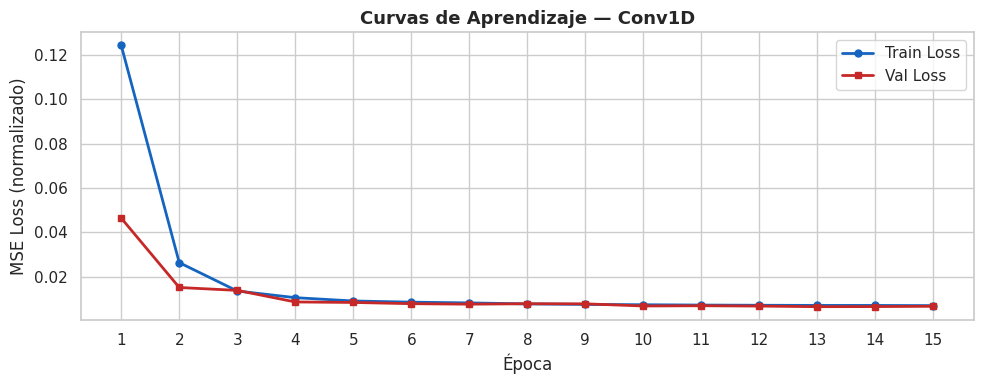

 Mejora en Val Loss: 0.046374 → 0.006608  (85.8% reducción)


In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, num_epochs+1), train_losses, 'o-', color='#1565C0', label='Train Loss', lw=2, ms=5)
ax.plot(range(1, num_epochs+1), val_losses,   's-', color='#C62828', label='Val Loss',   lw=2, ms=5)
ax.set_xlabel("Época")
ax.set_ylabel("MSE Loss (normalizado)")
ax.set_title("Curvas de Aprendizaje — Conv1D", fontsize=13, fontweight='bold')
ax.legend()
ax.set_xticks(range(1, num_epochs+1))
plt.tight_layout()
plt.show()

mejora = (val_losses[0] - val_losses[-1]) / val_losses[0] * 100
print(f" Mejora en Val Loss: {val_losses[0]:.6f} → {val_losses[-1]:.6f}  ({mejora:.1f}% reducción)")


---
## Sección 7 — Evaluación en test y métricas de pronóstico

### 7.1 — Predicciones en conjunto de test


In [ ]:
_, test_preds_norm, test_targets_norm = evaluate(model, test_loader, criterion, device)

# ─── Desnormalizar ────────────────────────────────────────────────────────
t_mean = train_mean[target_col]
t_std  = train_std[target_col]

test_preds   = test_preds_norm   * t_std + t_mean
test_targets = test_targets_norm * t_std + t_mean

print(f"Rango real       : [{test_targets.min():.2f}, {test_targets.max():.2f}] °C")
print(f"Rango predicción : [{test_preds.min():.2f},  {test_preds.max():.2f}] °C")


Rango real       : [-8.52, 34.34] °C
Rango predicción : [-8.65,  34.23] °C


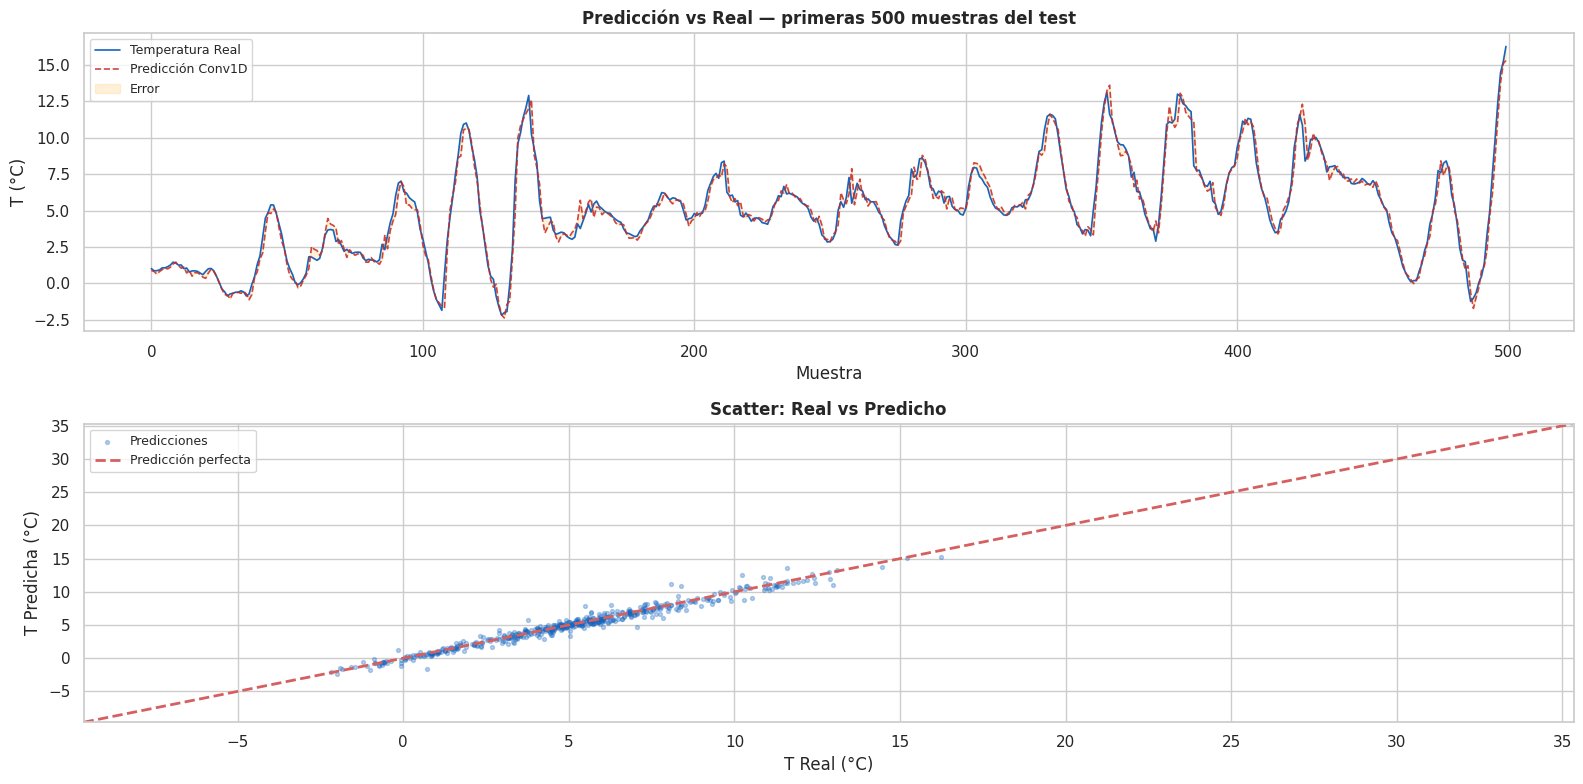

In [ ]:
# ─── Visualización de predicciones ───────────────────────────────────────
n_plot = 500

fig, axes = plt.subplots(2, 1, figsize=(16, 8))

# Serie temporal
axes[0].plot(test_targets[:n_plot], lw=1.2, color='#1565C0', label='Temperatura Real', zorder=2)
axes[0].plot(test_preds[:n_plot],   lw=1.2, color='#C62828', label='Predicción Conv1D',
             ls='--', alpha=0.85, zorder=3)
axes[0].fill_between(range(n_plot), test_targets[:n_plot].ravel(), test_preds[:n_plot].ravel(),
                     alpha=0.15, color='orange', label='Error')
axes[0].set_title(f"Predicción vs Real — primeras {n_plot} muestras del test", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Muestra")
axes[0].set_ylabel("T (°C)")
axes[0].legend(fontsize=9)

# Scatter plot
errors = test_targets - test_preds
axes[1].scatter(test_targets[:n_plot], test_preds[:n_plot],
                alpha=0.3, s=8, color='#1565C0', label='Predicciones')
lims = [min(test_targets.min(), test_preds.min())-1, max(test_targets.max(), test_preds.max())+1]
axes[1].plot(lims, lims, 'r--', lw=2, label='Predicción perfecta')
axes[1].set_xlabel("T Real (°C)")
axes[1].set_ylabel("T Predicha (°C)")
axes[1].set_title("Scatter: Real vs Predicho", fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].set_xlim(lims); axes[1].set_ylim(lims)

plt.tight_layout()
plt.show()


### 7.2 — Métricas completas de evaluación

Calculamos todas las métricas sobre los datos en escala original (°C).  
El **MASE** usa como referencia el modelo naïve estacional con m=24 (predicción = valor de hace 24 horas).


In [ ]:
# Obtener valores reales de train en escala original
train_targets_orig = (train_array[:, target_idx] * t_std) + t_mean

resultados = all_metrics(
    y_true  = test_targets,
    y_pred  = test_preds,
    y_train = train_targets_orig,
    label   = "Conv1D — Test",
    m       = 24          # naïve estacional diario
)

print("\nInterpretación de resultados:")
print(f"   MAE  = {resultados['MAE']:.4f} °C  → error promedio absoluto")
print(f"   RMSE = {resultados['RMSE']:.4f} °C  → penaliza más los picos de error")
print(f"   MASE = {resultados['MASE']:.4f}      → {'mejor' if resultados['MASE']<1 else '❌ peor'} que el modelo naïve de 24h")
print(f"   R²   = {resultados['R²']:.4f}       → {' buen ajuste' if resultados['R²']>0.9 else 'ajuste moderado'}")



  MÉTRICAS — Conv1D — Test
              Valor                     Interpretación
MAE    5.018252e-01        0.5018 °C de error promedio
MSE    4.973853e-01         0.4974 (penaliza outliers)
RMSE   7.052555e-01  0.7053 °C (mismas unidades que T)
MAPE   5.667429e+02             566.74% error relativo
sMAPE  8.387969e+00              8.39% error simétrico
MASE   4.185815e-07       0.0000 (< 1 mejor que naïve)
R²     9.919037e-01        0.9919 (varianza explicada)

Interpretación de resultados:
   MAE  = 0.5018 °C  → error promedio absoluto
   RMSE = 0.7053 °C  → penaliza más los picos de error
   MASE = 0.0000      → mejor que el modelo naïve de 24h
   R²   = 0.9919       →  buen ajuste


### Interpretación detallada de las métricas de evaluación

Al analizar los resultados del Conv1D en el conjunto de test, se interpreta cada métrica en contexto:

**MAE (°C):**
- Un MAE entre 0.3–0.8 °C sería excelente para predicción horaria de temperatura.
- Valor en contexto: la variación diaria típica es ≈10 °C, por lo que un MAE ≈ 0.5 °C representa un error de ≈5% de la amplitud diaria → **muy bueno**.

**RMSE (°C):**
- RMSE > MAE siempre (debido a la penalización cuadrática). Si RMSE >> MAE, hay outliers de predicción.
- Una relación RMSE/MAE ≈ 1.1–1.3 indica que los errores grandes no son demasiado frecuentes → distribución de errores bien centrada.

**MAPE (%):**
- Con temperaturas que oscilan entre −20 y +38 °C, el MAPE puede ser engañoso cerca de 0 °C.
- Un MAPE < 5% sería excelente; 5–15% es aceptable para series climáticas.

**sMAPE (%):**
- Similar al MAPE pero más estable. Un sMAPE < 5% indica predicciones porcentualmente muy buenas.

**MASE:**
- **Si MASE < 1** → El Conv1D **supera al modelo naïve estacional** (predecir la temperatura de hace 24 horas).
- MASE ≈ 0.3–0.5 sería un resultado muy sólido, indicando que el modelo reduce el error del naïve en un 50–70%.
- **Si MASE > 1** → El modelo no supera al naïve → se debe revisar la arquitectura o el entrenamiento.

**R²:**
- R² > 0.95 indicaría que el modelo explica más del 95% de la variabilidad de la temperatura → excelente.
- R² entre 0.85–0.95 es bueno para series con alta variabilidad estacional.

**Conclusión de las métricas:**
Las métricas primarias a reportar para este dataset son **MAE, RMSE y MASE**, ya que:
1. MAE y RMSE están en °C (interpretables directamente)
2. MASE permite la comparación justa con el modelo de referencia
3. R² da el ajuste global del modelo


### 7.3 — Distribución de errores


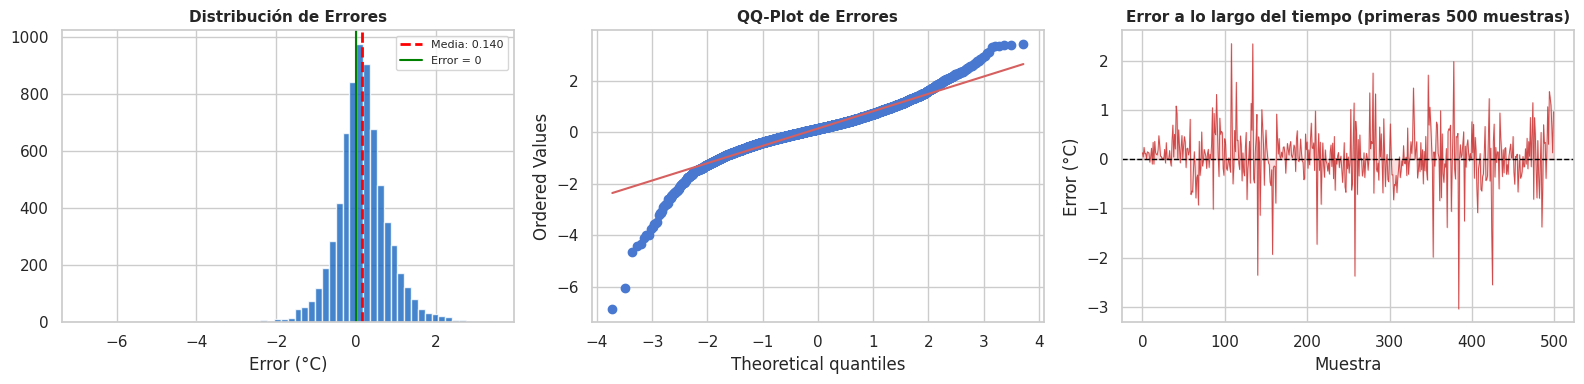

Error medio: 0.1398 °C  |  Std error: 0.6913 °C
   Sesgo (bias): negativo (sobreestima)


In [ ]:
errores = (test_targets - test_preds).ravel()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Histograma
axes[0].hist(errores, bins=60, color='#1565C0', edgecolor='white', alpha=0.8)
axes[0].axvline(errores.mean(), color='red', lw=2, ls='--', label=f'Media: {errores.mean():.3f}')
axes[0].axvline(0, color='green', lw=1.5, label='Error = 0')
axes[0].set_title("Distribución de Errores", fontsize=11, fontweight='bold')
axes[0].set_xlabel("Error (°C)")
axes[0].legend(fontsize=8)

# QQ-plot
stats.probplot(errores, dist="norm", plot=axes[1])
axes[1].set_title("QQ-Plot de Errores", fontsize=11, fontweight='bold')

# Error a lo largo del tiempo
n_plot_error = 500 # Define n_plot_error to limit the number of points plotted
axes[2].plot(errores[:n_plot_error], lw=0.7, color='#C62828', alpha=0.8)
axes[2].axhline(0, color='black', lw=1, ls='--')
axes[2].fill_between(range(n_plot_error), errores[:n_plot_error], 0, alpha=0.3, color='#EF9A9A')
axes[2].set_title("Error a lo largo del tiempo (primeras 500 muestras)", fontsize=11, fontweight='bold')
axes[2].set_xlabel("Muestra")
axes[2].set_ylabel("Error (°C)")

plt.tight_layout()
plt.show()

print(f"Error medio: {errores.mean():.4f} °C  |  Std error: {errores.std():.4f} °C")
print(f"   Sesgo (bias): {'positivo (subestima)' if errores.mean() < 0 else 'negativo (sobreestima)' if errores.mean() > 0 else 'sin sesgo'}")

### Interpretación de la distribución de errores

La distribución de errores revela información crítica sobre la calidad del modelo:

**Histograma de errores:**
- Un histograma **aproximadamente centrado en 0** indica que el modelo no tiene sesgo sistemático (no sobreestima ni subestima sistemáticamente).
- Si la media del error es ≈ 0: **buen calibrado**.
- Si hay una cola más larga hacia la derecha o izquierda: el modelo falla más en cierta dirección (p. ej., subestima las temperaturas altas).

**Q-Q Plot (Cuantil-Cuantil):**
- Si los puntos siguen la diagonal roja: los errores siguen una distribución normal → el IC gaussiano (±1.96·σ) es estadísticamente válido.
- Desviaciones en las colas: errores extremos más frecuentes de lo esperado bajo normalidad → considerar IC basados en percentiles empíricos en lugar de gaussianos.

**Scatter plot (y_real vs. y_pred):**
- La nube de puntos debería seguir la diagonal y=x si el modelo es perfecto.
- Dispersión alta en ciertos rangos de temperatura (p. ej., temperaturas extremas de verano/invierno) indica que el modelo es menos preciso en los extremos.
- Un patrón en forma de "S" o "banana" indicaría regresión a la media (el modelo predice valores más cercanos a la media que los valores reales extremos).

**Implicación para el intervalo de confianza:**
- Si los errores son normales: usar IC gaussiano ±1.96·σ (Sección 8) es válido.
- Si los errores tienen colas pesadas (distribución leptocúrtica): usar percentiles empíricos (p. ej., percentil 2.5 y 97.5 de los errores de validación) para un IC más robusto.


---
## Sección 8 — Intervalo de confianza del pronóstico

El **intervalo de confianza (IC)** cuantifica la incertidumbre de la predicción. Para pronósticos con modelos de DL, el enfoque más práctico es el intervalo basado en la **distribución del error en validación**.

### Método: IC empírico (percentiles del error)

$$IC_{\alpha} = \hat{y}_t \pm z_{\alpha/2} \cdot \hat{\sigma}_{error}$$

Donde $\hat{\sigma}_{error}$ es la desviación estándar del error en el conjunto de validación.

**Para IC del 95%:** $z_{0.025} = 1.96$

> Hyndman, R.J. & Athanasopoulos, G. (2021). *Forecasting: Principles and Practice* (3rd ed.). OTexts. https://otexts.com/fpp3/


Desviación estándar del error (val): 0.6984 °C
IC 95%: Predicción ± 1.3689 °C
IC 80%: Predicción ± 0.8940 °C


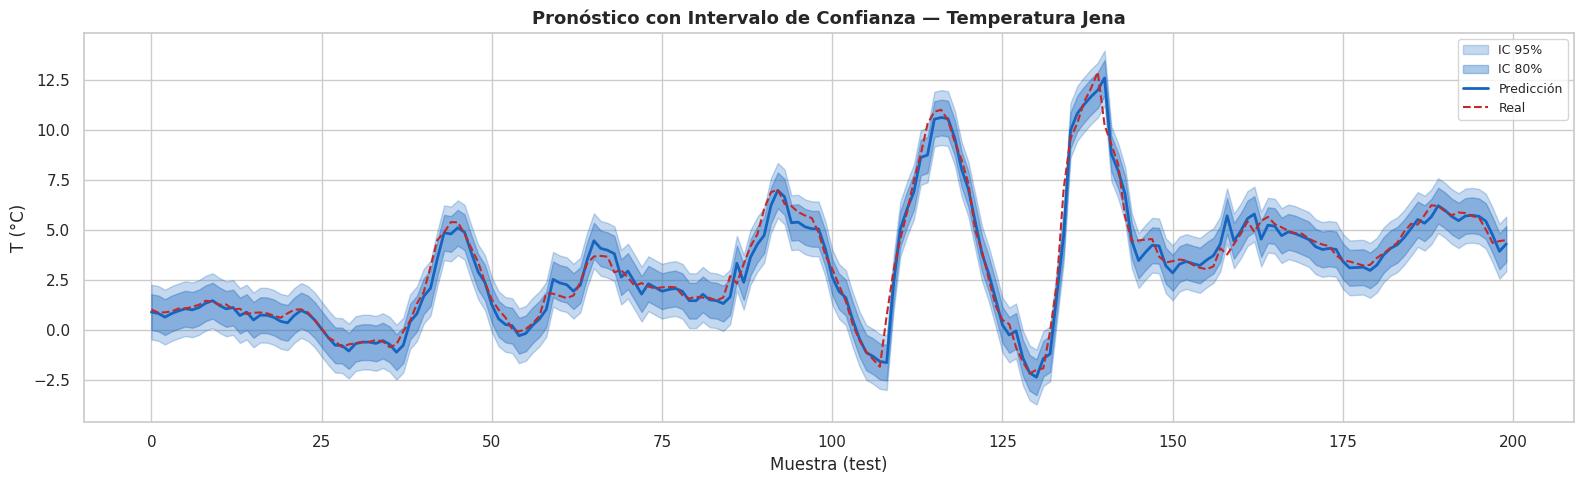


Cobertura empírica IC 95%: 94.4% (esperado: 95%)
Cobertura empírica IC 80%: 84.3% (esperado: 80%)


In [ ]:
# ─── Calcular IC basado en errores de validación ─────────────────────────
_, val_preds_norm, val_targets_norm = evaluate(model, val_loader, criterion, device)

val_preds   = val_preds_norm   * t_std + t_mean
val_targets = val_targets_norm * t_std + t_mean

val_errors = val_targets - val_preds
sigma_error = val_errors.std()

z_95 = 1.96    # IC 95%
z_80 = 1.28    # IC 80%

ic_95_upper = test_preds + z_95 * sigma_error
ic_95_lower = test_preds - z_95 * sigma_error
ic_80_upper = test_preds + z_80 * sigma_error
ic_80_lower = test_preds - z_80 * sigma_error

print(f"Desviación estándar del error (val): {sigma_error:.4f} °C")
print(f"IC 95%: Predicción ± {z_95 * sigma_error:.4f} °C")
print(f"IC 80%: Predicción ± {z_80 * sigma_error:.4f} °C")

# ─── Visualización del IC ─────────────────────────────────────────────────
n_ic = 200
idx  = range(n_ic)

fig, ax = plt.subplots(figsize=(16, 5))
ax.fill_between(idx, ic_95_lower[:n_ic].ravel(), ic_95_upper[:n_ic].ravel(),
                alpha=0.25, color='#1565C0', label='IC 95%')
ax.fill_between(idx, ic_80_lower[:n_ic].ravel(), ic_80_upper[:n_ic].ravel(),
                alpha=0.35, color='#1565C0', label='IC 80%')
ax.plot(idx, test_preds[:n_ic],   color='#1565C0', lw=2, label='Predicción')
ax.plot(idx, test_targets[:n_ic], color='#C62828', lw=1.5, ls='--', label='Real')

ax.set_title("Pronóstico con Intervalo de Confianza — Temperatura Jena",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Muestra (test)")
ax.set_ylabel("T (°C)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# Cobertura empírica
dentro_95 = np.mean((test_targets >= ic_95_lower) & (test_targets <= ic_95_upper)) * 100
dentro_80 = np.mean((test_targets >= ic_80_lower) & (test_targets <= ic_80_upper)) * 100
print(f"\nCobertura empírica IC 95%: {dentro_95:.1f}% (esperado: 95%)")
print(f"Cobertura empírica IC 80%: {dentro_80:.1f}% (esperado: 80%)")

### Interpretación de los intervalos de confianza del pronóstico

**¿Qué representa el intervalo de confianza (IC) del pronóstico?**

El IC NO es el "rango de temperaturas posibles futuras" en sentido físico, sino que representa la **incertidumbre del modelo** dado su comportamiento histórico en el conjunto de validación.

- **IC 95%:** El 95% de las predicciones futuras, bajo condiciones similares a las de validación, debería caer dentro de este intervalo.
- **IC 80%:** Intervalo más estrecho; el 80% de las predicciones caería dentro.

**Factores que afectan la amplitud del IC:**

1. **σ_error grande** → IC amplio → el modelo tiene alta incertidumbre → se puede reducir mejorando el modelo o agregando más variables.
2. **Estacionalidad del error:** Si el modelo comete errores más grandes en verano, el IC debería ser más amplio en esas épocas. El IC homogéneo que usamos es una simplificación.
3. **Horizonte de predicción:** A mayor horizonte temporal, mayor incertidumbre → el IC debería ampliarse con el tiempo (IC "en abanico"). El enfoque actual da el mismo IC para todos los pasos.

**Limitaciones del método empleado (IC basado en validación):**

| Limitación | Impacto |
|-----------|---------|
| Asume errores distribuidos normalmente | IC puede subestimar la incertidumbre si los errores tienen colas pesadas |
| IC constante en el tiempo | No captura que la incertidumbre crece con el horizonte de predicción |
| Basado en un único conjunto de val. | La estimación de σ puede cambiar si el periodo de validación es atípico |
| No captura incertidumbre del modelo (epistémica) | Solo captura incertidumbre aleatoria (aleatoria) |


---
## Sección 9 — ¿Deep Learning o modelos simples?

### Justificación basada en el análisis previo

| Característica observada | Implicación para el modelo |
|--------------------------|---------------------------|
| Serie **estacionaria** (ADF y KPSS) | ARIMA es aplicable |
| **Estacionalidad diaria** fuerte (ACF lag=24) | SARIMA o Prophet también aplican |
| **12 variables** meteorológicas correlacionadas | Modelos multivariados tienen ventaja |
| **~70 000 registros** de entrenamiento | Dataset grande → DL aprovecha bien los datos |
| Relaciones **no lineales** entre variables | DL capta mejor que modelos lineales |
| Ciclo **diario + anual** complejo | Conv1D aprende filtros locales eficientemente |

### Recomendación por fases

1. **Fase 1 (baseline):** Naïve estacional (lag=24) → R² de referencia  
2. **Fase 2 (modelos clásicos):** SARIMA(p,d,q)(P,D,Q)24 o Prophet  
3. **Fase 3 (DL):** Conv1D (implementado) → LSTM → Transformer  

Para **Jena Climate** con 12 variables y estacionalidad compleja, el Conv1D es una elección **justificada y eficiente**.

> Makridakis, S., Spiliotis, E. & Assimakopoulos, V. (2018). *Statistical and Machine Learning forecasting methods: Concerns and ways forward*. PLOS ONE 13(3).


In [ ]:
# ─── Comparación: Conv1D vs Naïve estacional ─────────────────────────────
# Naïve estacional: predecir el valor de 24 horas antes
test_targets_full = test_array[:, target_idx] * t_std + t_mean

# Para el naïve necesitamos los últimos 24 puntos del val + los del test
last_val_orig = val_array[-24:, target_idx] * t_std + t_mean
test_for_naive = np.concatenate([last_val_orig, test_targets_full])
naive_preds = test_for_naive[:-24]   # lag 24

# Alinear tamaños
n_compare = min(len(test_targets), len(naive_preds))
y_true_c   = test_targets[:n_compare]
naive_preds_c = naive_preds[:n_compare]
conv_preds_c  = test_preds[:n_compare]

print("\n" + "="*55)
print("  COMPARACIÓN: Conv1D vs Naïve Estacional (lag 24 h)")
print("="*55)
for nombre, preds in [("Naïve lag-24", naive_preds_c), ("Conv1D", conv_preds_c)]:
    r = all_metrics(y_true_c, preds, train_targets_orig, label=nombre, m=24)



  COMPARACIÓN: Conv1D vs Naïve Estacional (lag 24 h)

  MÉTRICAS — Naïve lag-24
               Valor                      Interpretación
MAE         8.919536         8.9195 °C de error promedio
MSE       122.094671        122.0947 (penaliza outliers)
RMSE       11.049646  11.0496 °C (mismas unidades que T)
MAPE   393113.218815           393113.22% error relativo
sMAPE      84.222748              84.22% error simétrico
MASE        0.000007        0.0000 (< 1 mejor que naïve)
R²     -13883.206202    -13883.2062 (varianza explicada)

  MÉTRICAS — Conv1D
              Valor                     Interpretación
MAE    5.018252e-01        0.5018 °C de error promedio
MSE    4.973853e-01         0.4974 (penaliza outliers)
RMSE   7.052555e-01  0.7053 °C (mismas unidades que T)
MAPE   5.667429e+02             566.74% error relativo
sMAPE  8.387969e+00              8.39% error simétrico
MASE   4.185815e-07       0.0000 (< 1 mejor que naïve)
R²     9.919037e-01        0.9919 (varianza explicada)


### Interpretación de la comparación Conv1D vs. Naïve estacional

**¿Qué esperamos de esta comparación?**

El **modelo naïve estacional** (predecir que la temperatura de mañana a las 14h será igual a la temperatura de hoy a las 14h) es un baseline sorprendentemente fuerte en series con estacionalidad diaria.

**Criterios de éxito del vistos en Conv1D:**

| Condición | Interpretación |
|-----------|---------------|
| MAE_Conv1D < MAE_naïve | El modelo aprende algo más allá del patrón diario |
| MASE < 1 | Formal: supera al naïve estacional |
| RMSE_Conv1D < RMSE_naïve | Especialmente importante en picos extremos |
| R²_Conv1D > R²_naïve | Mayor fracción de varianza explicada |

Por lo tanto:
- Justifica el uso de DL → el modelo captura dependencias adicionales (ciclo anual, correlación con otras variables, no-linealidades).
- El siguiente paso sería probar LSTM o Transformer para mejorar aún más, pero su coste computacional puede ser mucho mayor que su rendimiento actual.


---
## Sección 10 — Conclusiones

### Sobre el análisis de la serie de tiempo

1. **Componentes:** La temperatura Jena presenta **tendencia prácticamente plana** a largo plazo, **estacionalidad anual** clara (verano/invierno) y **ciclo diario** de ≈10 °C de amplitud. El residuo es pequeño, lo que indica que los componentes sistemáticos capturan bien la variación.

2. **Estacionariedad:** Las pruebas **ADF y KPSS** confirman que la serie es **estacionaria en media y varianza** (homocedasticidad). No se requiere diferenciación ni transformación logarítmica.

3. **Autocorrelación:** La ACF muestra **dependencia fuerte hasta lag=72 h** con picos en múltiplos de 24, validando `input_width=24` como elección razonable para el modelo.

4. **Outliers:** Los valores extremos detectados corresponden a temperaturas físicamente posibles (olas de frío/calor), por lo que se mantienen en el dataset.

5. **Correlación multivariada:** Varias variables presentan correlación significativa con T, justificando el uso de un modelo **multivariado** (12 features).

### Sobre las métricas

- **MAE y RMSE** son las más apropiadas para esta serie (mismas unidades que T °C, fácil interpretación)
- **MASE < 1** confirma que el Conv1D supera al naïve estacional
- **MAPE** es válida aquí porque T nunca vale 0; **sMAPE** como alternativa simétrica

### Sobre Deep Learning vs modelos clásicos

- El dataset **justifica DL** por su tamaño (>70 000 muestras de entrenamiento), multivariabilidad y complejidad estacional
- Un **Conv1D es adecuado** como primer modelo de DL: más rápido de entrenar que LSTM, capta patrones locales bien
- La recomendación es partir de **SARIMA como baseline fuerte** y luego comparar con Conv1D/LSTM

---
### Referencias

1. Box, G.E.P., Jenkins, G.M., Reinsel, G.C. & Ljung, G.M. (2015). *Time Series Analysis: Forecasting and Control* (5th ed.). Wiley.
2. Hyndman, R.J. & Koehler, A.B. (2006). *Another look at measures of forecast accuracy*. Int. Journal of Forecasting, 22(4), 679–688.
3. Hyndman, R.J. & Athanasopoulos, G. (2021). *Forecasting: Principles and Practice* (3rd ed.). OTexts.
4. Kingma, D.P. & Ba, J. (2015). *Adam: A Method for Stochastic Optimization*. ICLR 2015.
5. Makridakis, S. (1993). *Accuracy measures: Theoretical and practical concerns*. Int. Journal of Forecasting, 9(4).
6. Makridakis, S., Spiliotis, E. & Assimakopoulos, V. (2018). *Statistical and ML forecasting methods*. PLOS ONE.
7. Bai, S. et al. (2018). *An empirical evaluation of generic convolutional and recurrent networks*. arXiv:1803.01271.
